# Drug Approval Analysis

This notebook analyzes drug approval data across multiple regulatory agencies.

## Setup

Before running burden-related analyses, preprocess the burden data:

```bash
python ./../src/burden_mapping/preprocess_burden_data.py
```

This will generate preprocessed burden data files in `data/Disease_burden_mapping/preprocessed/`

In [133]:
import os
import sys
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib.ticker import FixedLocator, ScalarFormatter

# Add src/ to import path when running from notebooks/
sys.path.insert(0, os.path.abspath('./../src'))

from burden_mapping.burden_utils import load_burden_data
import analysis.analysis_utils as analysis_utils

# Explicit aliases keep notebook symbols visible to static analysis (Pylance).
get_agency_data = analysis_utils.get_agency_data
plot_timeline = analysis_utils.plot_timeline
plot_some_class_per_year_panel = analysis_utils.plot_some_class_per_year_panel
plot_some_class_per_year_single = analysis_utils.plot_some_class_per_year_single
plot_drug_class_per_decision_year_absolute = analysis_utils.plot_drug_class_per_decision_year_absolute
plot_drug_class_distribution_pie = analysis_utils.plot_drug_class_distribution_pie
plot_drug_class_distribution_pie_panel = analysis_utils.plot_drug_class_distribution_pie_panel
plot_drug_class_per_year = analysis_utils.plot_drug_class_per_year
plot_administration_route_per_year = analysis_utils.plot_administration_route_per_year
plot_drug_class_by_pharmaceutical_form = analysis_utils.plot_drug_class_by_pharmaceutical_form
plot_pharmaceutical_form_per_year = analysis_utils.plot_pharmaceutical_form_per_year
plot_disease_class_per_decision_year_absolute = analysis_utils.plot_disease_class_per_decision_year_absolute
plot_marketing_holder_distribution_pie = analysis_utils.plot_marketing_holder_distribution_pie
plot_review_duration_by_agency = analysis_utils.plot_review_duration_by_agency
plot_review_duration_by_disease_class = analysis_utils.plot_review_duration_by_disease_class
plot_decision_distribution_by_agency = analysis_utils.plot_decision_distribution_by_agency
plot_nonclinical_abridged_distribution = analysis_utils.plot_nonclinical_abridged_distribution
plot_orphan_drug_status_distribution = analysis_utils.plot_orphan_drug_status_distribution
plot_disease_class_per_drug_class_panel = analysis_utils.plot_disease_class_per_drug_class_panel
plot_pie_disease_class_per_drug_class_panel = analysis_utils.plot_pie_disease_class_per_drug_class_panel
plot_burden_vs_approvals_combined = analysis_utils.plot_burden_vs_approvals_combined

In [134]:
DECISION_FILTER = "approved" # "approved" or "all_decisions"
DATASET_FILTER = "" # "" or "_pars" or "_nonpars"

In [135]:
DATASET_DIR = f"./../data/datasets/1995/{DECISION_FILTER}"
OVERALL_PATH = f"{DATASET_DIR}/Overall.csv"

SAVE_DIR = os.path.abspath(f"./../analysis/1995{DATASET_FILTER}/{DECISION_FILTER}")
os.makedirs(SAVE_DIR, exist_ok=True)

In [136]:
# Load Overall dataset once
print("Loading Overall dataset...")
Overall = pd.read_csv(OVERALL_PATH)
print(f"Overall (full dataset): {len(Overall)} rows")

# Define which agencies to analyze (comment/uncomment as needed)
if DATASET_FILTER == "_nonpars":
    AGENCIES_TO_ANALYZE = ['FDA', 'HealthCanada']
elif DATASET_FILTER == "_pars":
    AGENCIES_TO_ANALYZE = [
        'EMA',
        # 'PMDA',
        'Swissmedic',
        'TGA']
elif DATASET_FILTER == "":
    AGENCIES_TO_ANALYZE = [
        'EMA',
        # 'PMDA',
        'Swissmedic',
        'TGA',
        'FDA',
        'HealthCanada'
    ]

DATASETS = {}
for agency in AGENCIES_TO_ANALYZE:
    DATASETS[agency] = Overall[Overall['Dataset'] == agency].copy()
    print(f"{agency}: {len(DATASETS[agency])} rows")

# Include Overall filtered to only selected agencies (for plotting)
DATASETS['Overall'] = Overall[Overall['Dataset'].isin(AGENCIES_TO_ANALYZE)].copy()
print(f"Overall (filtered to {len(AGENCIES_TO_ANALYZE)} selected agencies): {len(DATASETS['Overall'])} rows")


Loading Overall dataset...
Overall (full dataset): 31556 rows
EMA: 1491 rows
Swissmedic: 233 rows
TGA: 988 rows
FDA: 18558 rows
HealthCanada: 10286 rows
Overall (filtered to 5 selected agencies): 31556 rows


In [137]:
# Initialize global variables in analysis_utils module
analysis_utils.Overall = Overall
analysis_utils.SAVE_DIR = SAVE_DIR
analysis_utils.DATASET_FILTER = DATASET_FILTER
print(f"Initialized analysis_utils with Overall ({len(Overall)} rows), SAVE_DIR={SAVE_DIR}, DATASET_FILTER='{DATASET_FILTER}'")

Initialized analysis_utils with Overall (31556 rows), SAVE_DIR=/Users/shtosti/Dropbox/Projects/DrugFork/analysis/1995/approved, DATASET_FILTER=''


In [138]:
# Create global colormaps for consistent colors across all plots
# IMPORTANT: Uses the full 'Overall' dataset (all agencies) to ensure consistent colors
# across different dataset filters (PAR/non-PAR) and agency selections

#######################################################################################################
# Drug class colormap (based on ALL agencies for consistency)
all_classes = Overall['Drug_class'].unique()
print(f"All unique drug classes ({len(all_classes)} total):", all_classes)
cmap = plt.get_cmap('tab20b')
colors = cmap(np.linspace(0, 1, len(all_classes)))
drug_class_colormap = dict(zip(all_classes, colors))

#######################################################################################################
# Disease class colormap
if 'Disease_class(es)' in Overall.columns:
    # Split semicolon-separated values and explode
    diseases = Overall['Disease_class(es)'].dropna().astype(str).str.split(';').explode().str.strip()
    all_disease_classes = diseases.unique()
    print(f"\nAll unique disease classes ({len(all_disease_classes)} total):", all_disease_classes)
    
    # Use a colormap with more colors for disease classes
    disease_cmap = plt.get_cmap('tab20b')
    disease_colors = disease_cmap(np.linspace(0, 1, len(all_disease_classes)))
    disease_class_colormap = dict(zip(all_disease_classes, disease_colors))
else:
    disease_class_colormap = {}
    print("\nDisease_class(es) column not found")

#######################################################################################################
# Administration route colormap (union of top 10 from each agency)
all_top10_routes = set()
if 'Administration_route' in Overall.columns and 'Dataset' in Overall.columns:
    for agency in Overall['Dataset'].unique():
        agency_df = Overall[Overall['Dataset'] == agency]
        routes = agency_df['Administration_route'].dropna().astype(str).str.split(';').explode().str.strip()
        top10 = routes.value_counts().nlargest(10).index.tolist()
        all_top10_routes.update(top10)
    
    # Convert to sorted list for consistent ordering
    all_top10_routes = sorted(list(all_top10_routes))
    print(f"\nUnion of top 10 administration routes from each agency ({len(all_top10_routes)} unique routes): {all_top10_routes}")
    
    # Use a colormap for administration routes
    if len(all_top10_routes) <= 20:
        admin_route_cmap = plt.get_cmap('tab20')
        admin_route_colors = [admin_route_cmap(i) for i in range(len(all_top10_routes))]
    else:
        admin_route_cmap = plt.get_cmap('tab20', len(all_top10_routes))
        admin_route_colors = [admin_route_cmap(i) for i in range(len(all_top10_routes))]
    admin_route_colormap = dict(zip(all_top10_routes, admin_route_colors))
else:
    admin_route_colormap = {}
    print("\nAdministration_route or Dataset column not found")

#####################################################################################################
# Pharmaceutical form colormap (union of top 10 from each agency)
all_top10_pharma_forms = set()
if 'Pharmaceutical_form' in Overall.columns and 'Dataset' in Overall.columns:
    for agency in Overall['Dataset'].unique():
        agency_df = Overall[Overall['Dataset'] == agency]
        forms = agency_df['Pharmaceutical_form'].dropna().astype(str).str.split(';').explode().str.strip()
        top10 = forms.value_counts().nlargest(10).index.tolist()
        all_top10_pharma_forms.update(top10)
    
    # Convert to sorted list for consistent ordering
    all_top10_pharma_forms = sorted(list(all_top10_pharma_forms))
    print(f"\nUnion of top 10 pharmaceutical forms from each agency ({len(all_top10_pharma_forms)} unique forms): {all_top10_pharma_forms}")
    
    # Use multiple qualitative colormaps for better color distribution
    num_forms = len(all_top10_pharma_forms)
    if num_forms <= 20:
        pharma_form_cmap = plt.get_cmap('tab20')
        pharma_form_colors = [pharma_form_cmap(i) for i in range(num_forms)]
    else:
        # Combine multiple colormaps for more colors
        colors_list = []
        tab20 = plt.get_cmap('tab20')
        tab20b = plt.get_cmap('tab20b')
        tab20c = plt.get_cmap('tab20c')
        set3 = plt.get_cmap('Set3')
        paired = plt.get_cmap('Paired')
        
        # Get colors from each colormap
        for i in range(20):
            colors_list.append(tab20(i))
        for i in range(20):
            colors_list.append(tab20b(i))
        for i in range(20):
            colors_list.append(tab20c(i))
        for i in range(12):
            colors_list.append(set3(i))
        for i in range(12):
            colors_list.append(paired(i))
        
        # Use only as many as we need
        pharma_form_colors = colors_list[:num_forms]
    
    pharma_form_colormap = dict(zip(all_top10_pharma_forms, pharma_form_colors))
else:
    pharma_form_colormap = {}
    print("\nPharmaceutical_form or Dataset column not found")


All unique drug classes (7 total): <StringArray>
[            'biologics', 'cell and gene therapy',        'small molecule',
               'vaccine', 'peptides and proteins',                 'other',
                     nan]
Length: 7, dtype: str

All unique disease classes (21 total): <StringArray>
[                      'endocrine, nutritional, and metabolic diseases',
                                                            'neoplasms',
                       'diseases of the blood and blood-forming organs',
                                     'mental and behavioural disorders',
                                    'infectious and parasitic diseases',
                                   'diseases of the respiratory system',
                                                 'diseases of the skin',
         'diseases of the musculoskeletal system and connective tissue',
                                     'diseases of the digestive system',
                                   'dise

In [139]:
# explore all Decision values
Overall.Decision.value_counts()

Decision
approved                               28921
marketed                                1519
conditional marketing authorisation     1116
Name: count, dtype: int64

In [140]:
# Explore Decision values by agency
for agency in Overall['Dataset'].unique():
    print(f"\n{agency}:")
    print(Overall[Overall['Dataset'] == agency]['Decision'].value_counts())



EMA:
Decision
approved                               1459
conditional marketing authorisation      32
Name: count, dtype: int64

Swissmedic:
Decision
approved                               205
conditional marketing authorisation     28
Name: count, dtype: int64

TGA:
Decision
approved    988
Name: count, dtype: int64

FDA:
Decision
approved                               17502
conditional marketing authorisation     1056
Name: count, dtype: int64

HealthCanada:
Decision
approved    8767
marketed    1519
Name: count, dtype: int64


In [141]:
for k,v in DATASETS.items():
    if 'Application_year' in v.columns:
        plot_timeline(v, col_name='Application_year', dataset_name=k)
    else:
        print(f"{k}: 'Application_year' column not found, skipping timeline plot.")


Original length: 1491, Final length after cleaning: 1399, Percentage kept: 93.83%
Original length: 233, Final length after cleaning: 233, Percentage kept: 100.00%
Original length: 988, Final length after cleaning: 499, Percentage kept: 50.51%
Original length: 18558, Final length after cleaning: 0, Percentage kept: 0.00%
FDA: All 18558 rows dropped after date_to_int for Application_year (all values invalid/null), skipping plot.
Original length: 10286, Final length after cleaning: 0, Percentage kept: 0.00%
HealthCanada: All 10286 rows dropped after date_to_int for Application_year (all values invalid/null), skipping plot.
Original length: 31556, Final length after cleaning: 2131, Percentage kept: 6.75%


In [142]:
for k,v in DATASETS.items():
    if 'Decision_year' in v.columns:
        plot_timeline(v, col_name='Decision_year', dataset_name=k)
    else:
        print(f"{k}: 'Decision_year' column not found, skipping timeline plot.")

Original length: 1491, Final length after cleaning: 1491, Percentage kept: 100.00%
Original length: 233, Final length after cleaning: 233, Percentage kept: 100.00%
Original length: 988, Final length after cleaning: 988, Percentage kept: 100.00%
Original length: 18558, Final length after cleaning: 18558, Percentage kept: 100.00%
Original length: 10286, Final length after cleaning: 10286, Percentage kept: 100.00%
Original length: 31556, Final length after cleaning: 31556, Percentage kept: 100.00%


In [143]:
# Show unique drug classes across all agencies
print("All drug classes (from full dataset):")
print(Overall["Drug_class"].unique())

# Optionally show per-agency
print("\nPer-agency drug classes:")
for agency in Overall['Dataset'].unique():
    print(f"\n{agency}:")
    print(get_agency_data(agency)["Drug_class"].unique())


All drug classes (from full dataset):
<StringArray>
[            'biologics', 'cell and gene therapy',        'small molecule',
               'vaccine', 'peptides and proteins',                 'other',
                     nan]
Length: 7, dtype: str

Per-agency drug classes:

EMA:
<StringArray>
[            'biologics', 'cell and gene therapy',        'small molecule',
               'vaccine', 'peptides and proteins',                 'other']
Length: 6, dtype: str

Swissmedic:
<StringArray>
['cell and gene therapy',        'small molecule',             'biologics',
               'vaccine',                 'other', 'peptides and proteins']
Length: 6, dtype: str

TGA:
<StringArray>
[            'biologics',        'small molecule',               'vaccine',
 'peptides and proteins',                 'other', 'cell and gene therapy']
Length: 6, dtype: str

FDA:
<StringArray>
['small molecule', 'other', 'peptides and proteins', nan, 'biologics']
Length: 5, dtype: str

HealthCanada:
<Stri

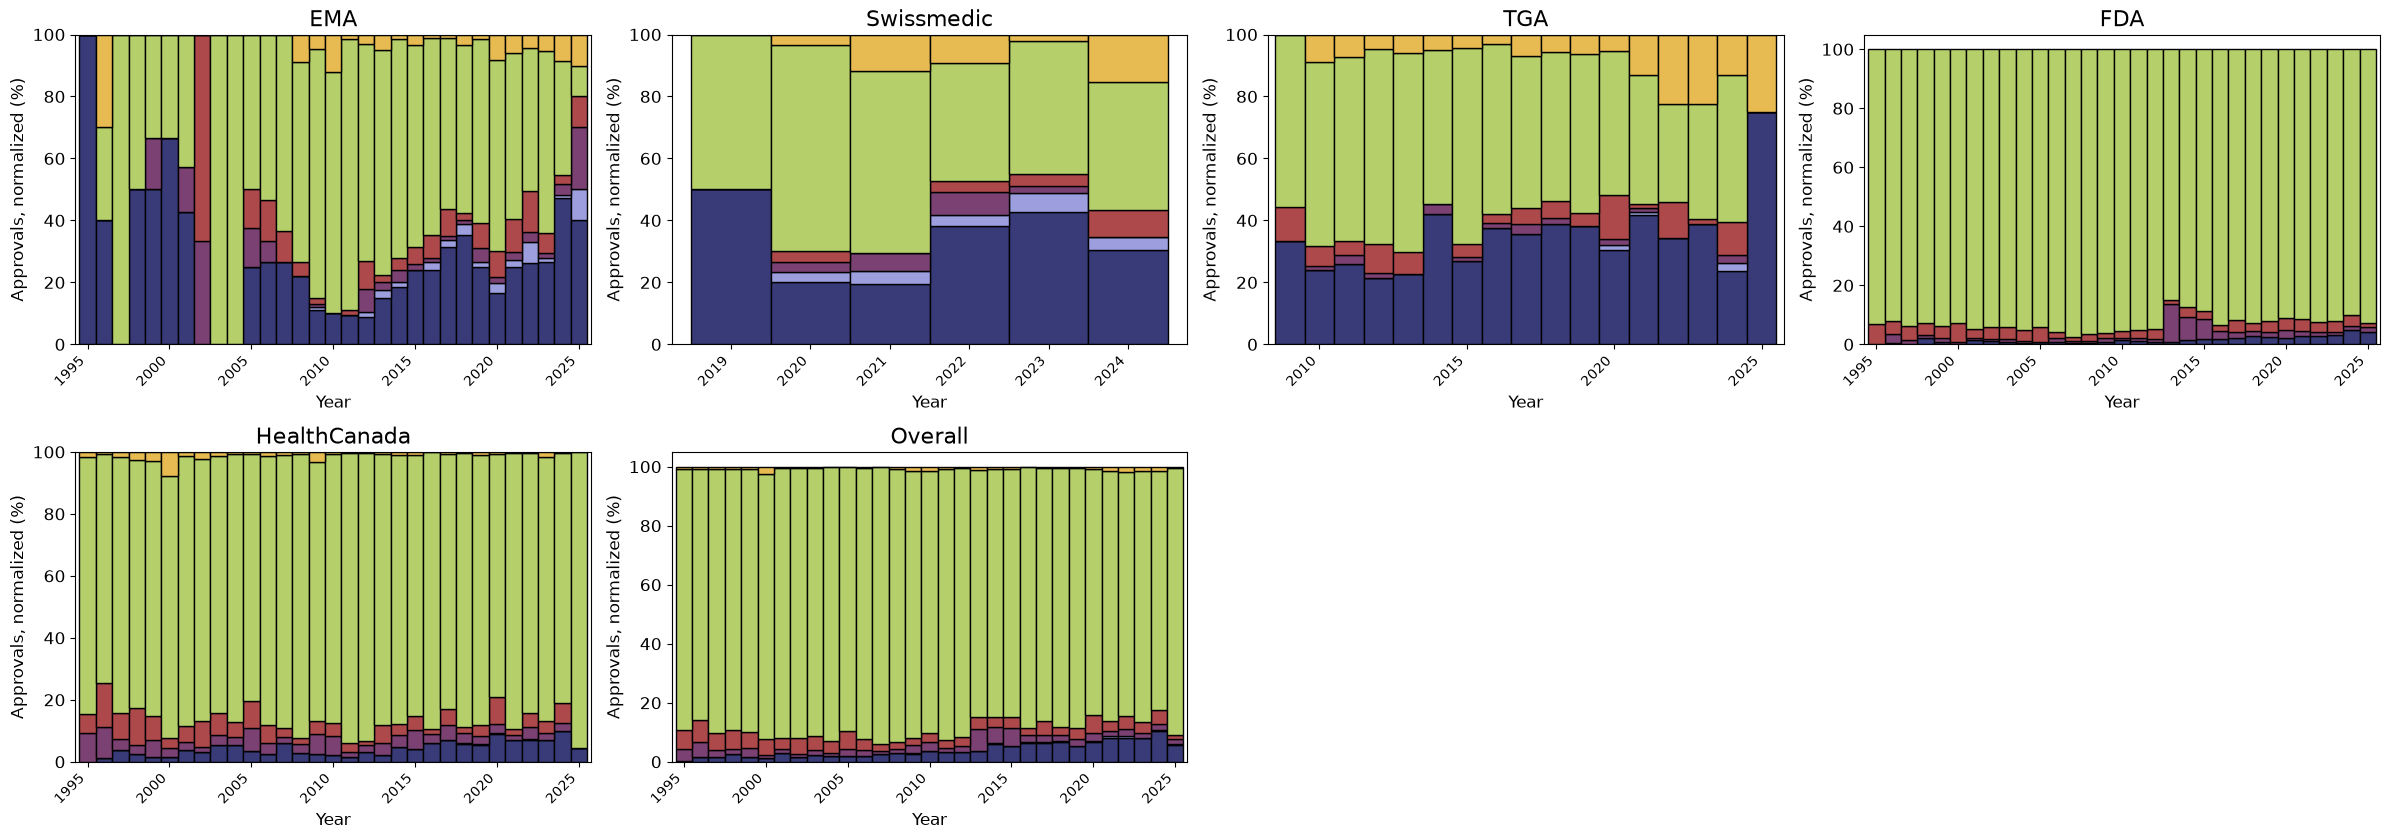

In [144]:
plot_some_class_per_year_panel(
    DATASETS, 
    bbox_to_anchor_val=(0.6, 0.2),
    date_col='Decision_year', 
    info_col="Drug_class",
    drug_class_colormap=drug_class_colormap, 
    nrows=3, 
    ncols=4,
    figsize_per_subplot=(6, 4)
)

Original length: 1491, Final length after cleaning: 1491, Percentage kept: 100.00%
Original length: 233, Final length after cleaning: 233, Percentage kept: 100.00%
Original length: 988, Final length after cleaning: 988, Percentage kept: 100.00%
Original length: 18212, Final length after cleaning: 18212, Percentage kept: 100.00%
Original length: 10286, Final length after cleaning: 10286, Percentage kept: 100.00%
Original length: 31210, Final length after cleaning: 31210, Percentage kept: 100.00%


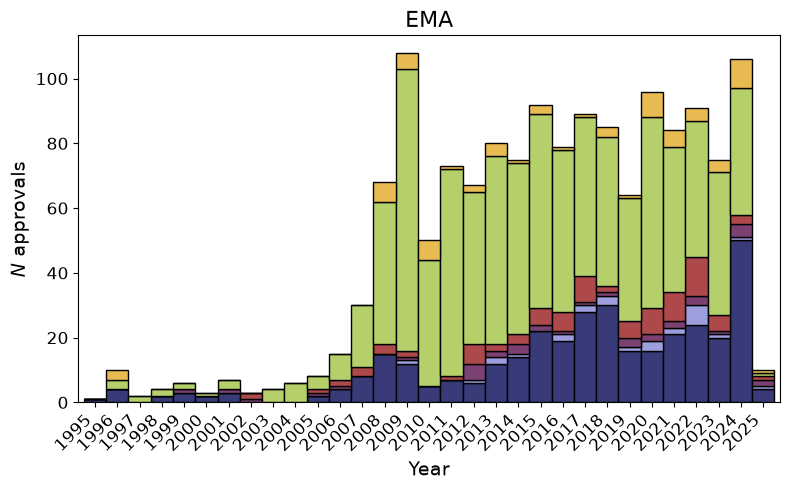

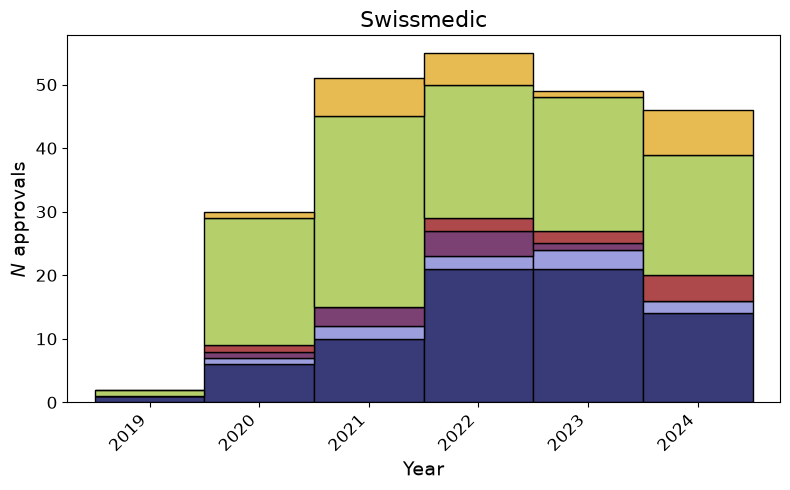

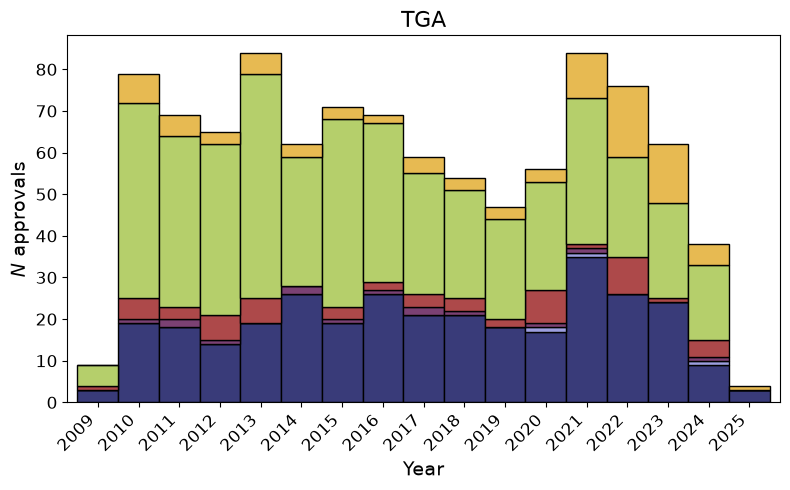

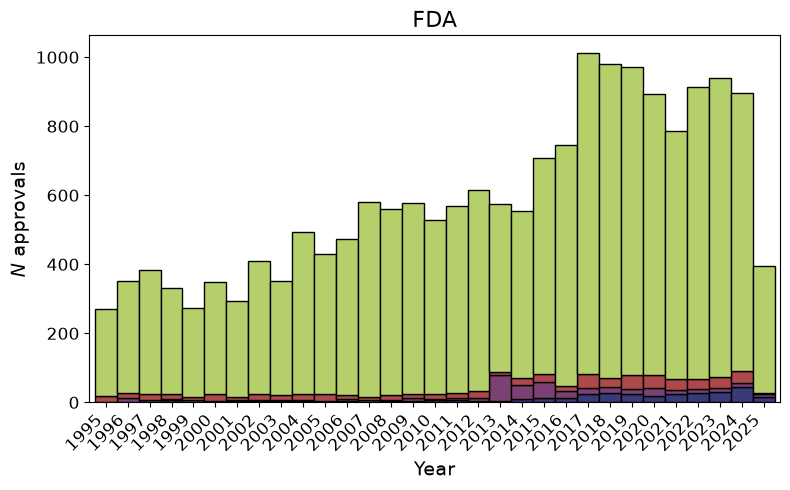

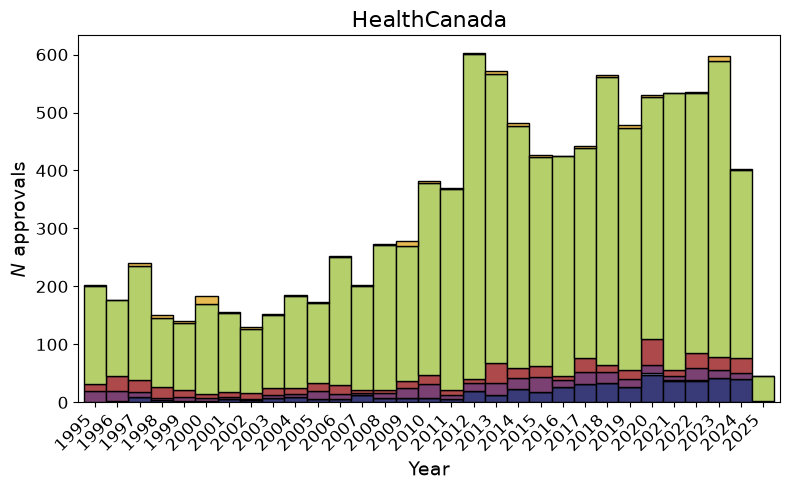

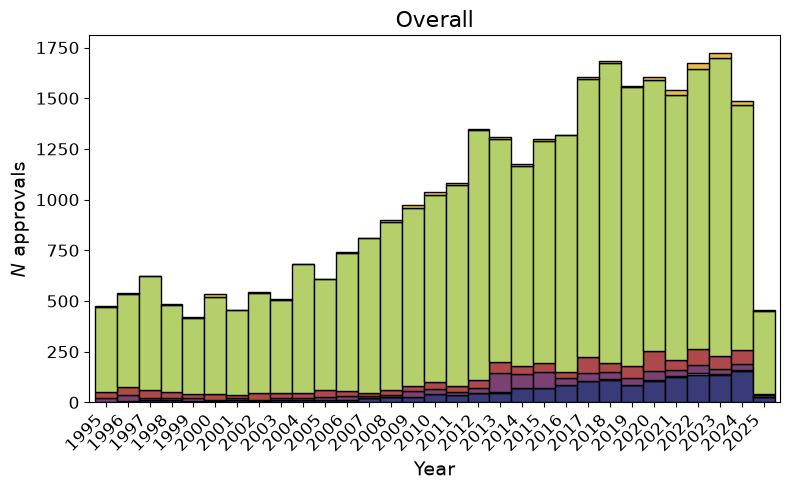

In [145]:
for k,v in DATASETS.items():
    if 'Decision_year' in v.columns:
        plot_drug_class_per_decision_year_absolute(v, drug_class_colormap=drug_class_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Decision_year' column not found, skipping drug class plot.")

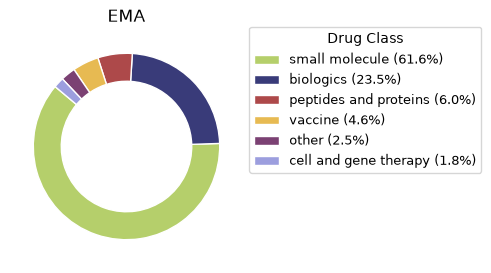

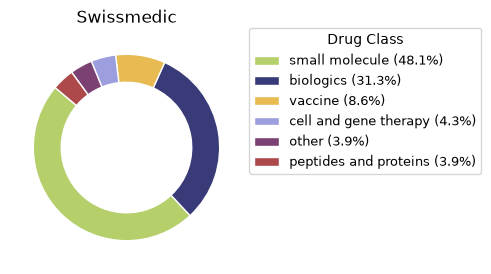

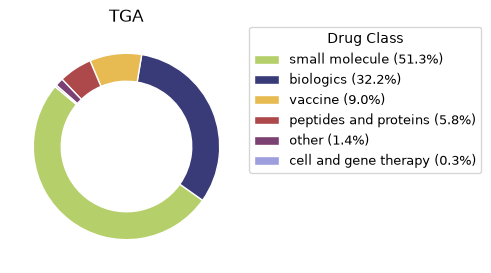

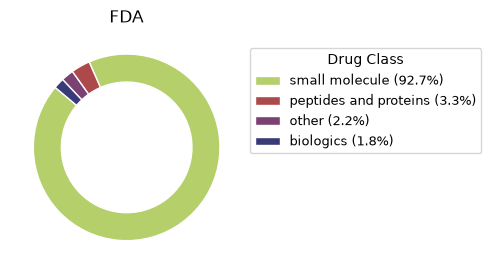

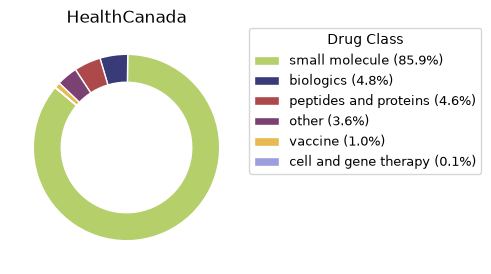

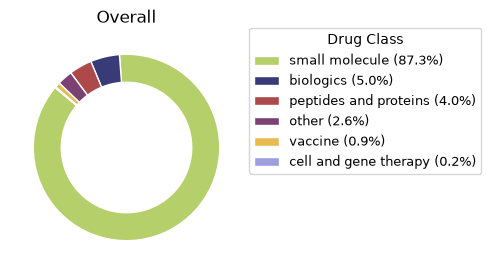

In [146]:
for k,v in DATASETS.items():
    if 'Drug_class' in v.columns:
        plot_drug_class_distribution_pie(v, drug_class_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Drug_class' column not found, skipping drug class distribution pie chart.")

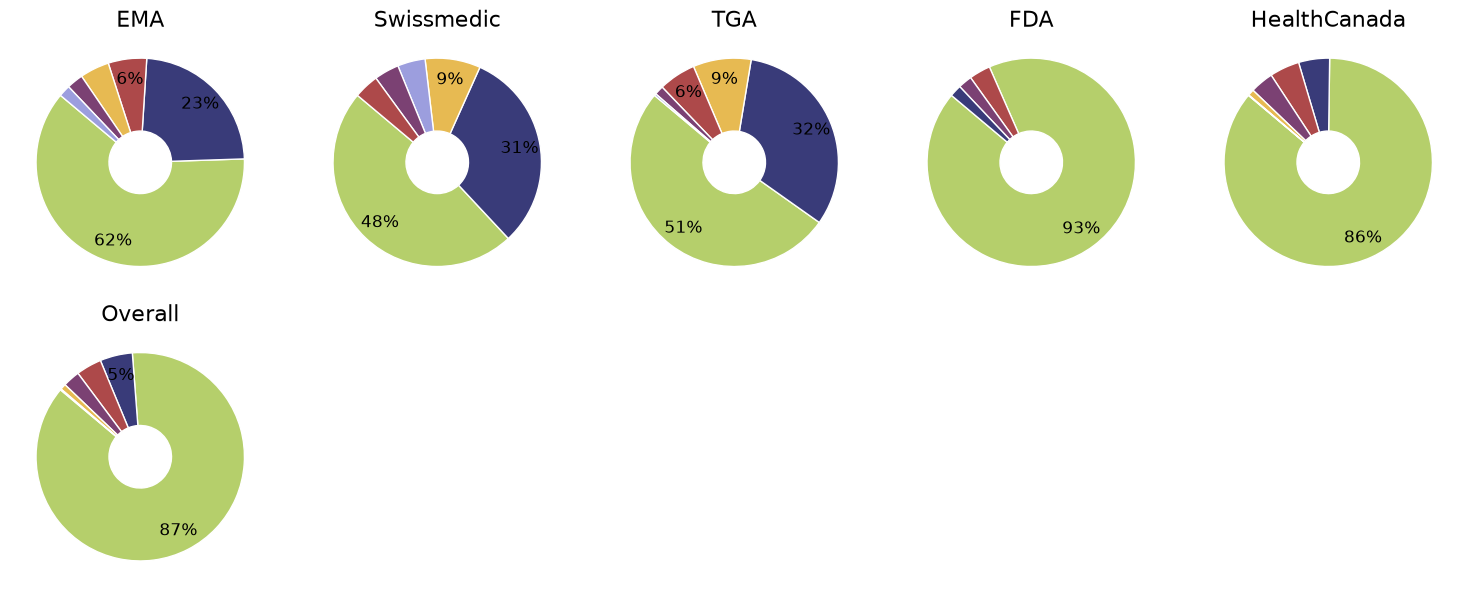

In [147]:
# Panel plot for drug class distribution (pie charts)
plot_drug_class_distribution_pie_panel(
    DATASETS, 
    drug_class_colormap=drug_class_colormap, 
    nrows=3, 
    ncols=5,
    figsize_per_subplot=(3, 3)
)

Original length: 1491, Final length after cleaning: 1491, Percentage kept: 100.00%
Original length: 233, Final length after cleaning: 233, Percentage kept: 100.00%
Original length: 988, Final length after cleaning: 988, Percentage kept: 100.00%
Original length: 18212, Final length after cleaning: 18212, Percentage kept: 100.00%
Original length: 10286, Final length after cleaning: 10286, Percentage kept: 100.00%
Original length: 31210, Final length after cleaning: 31210, Percentage kept: 100.00%


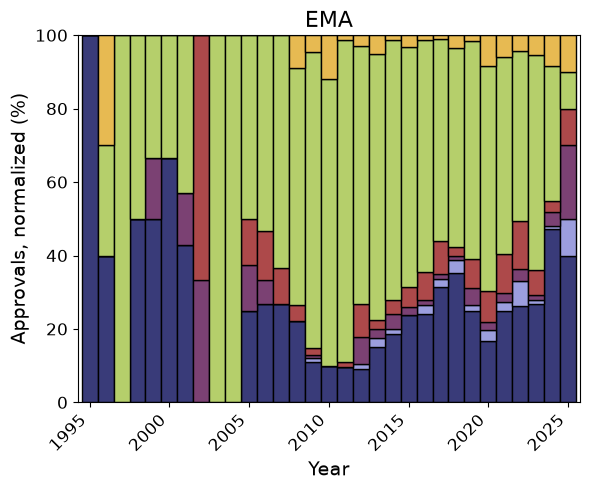

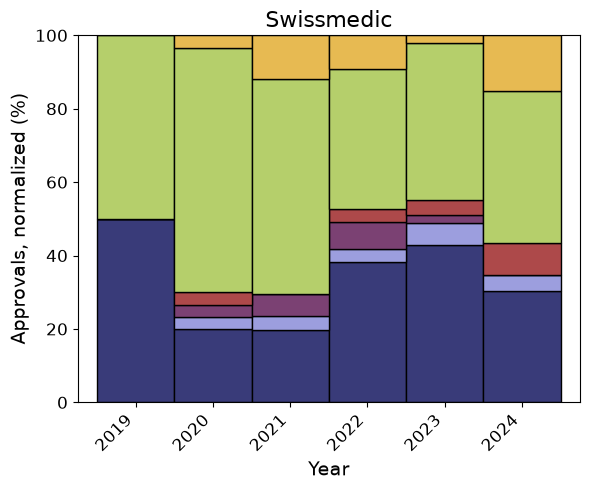

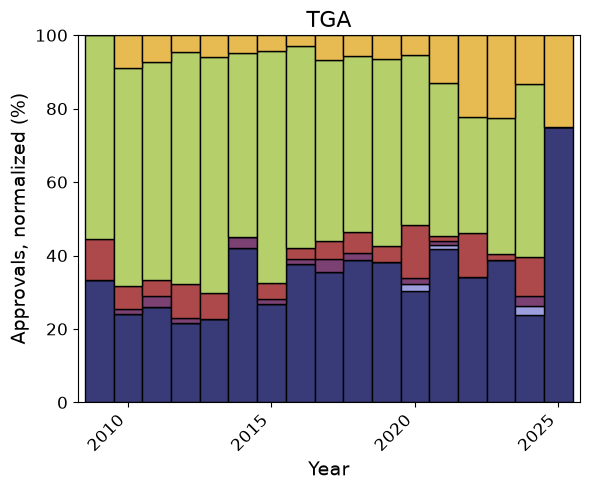

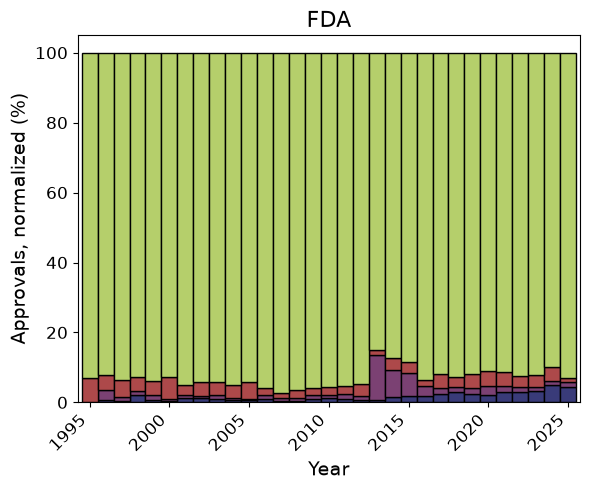

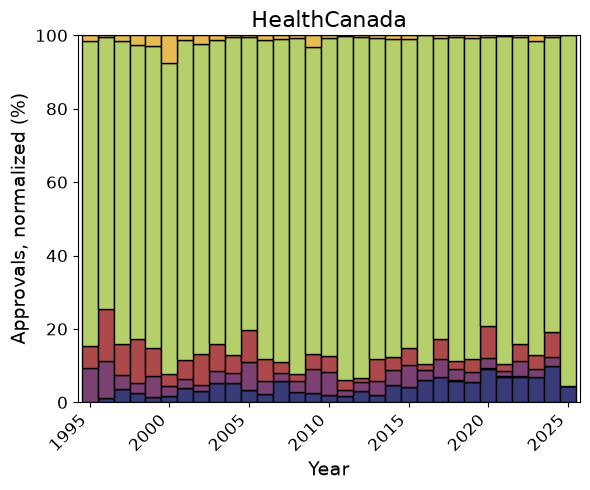

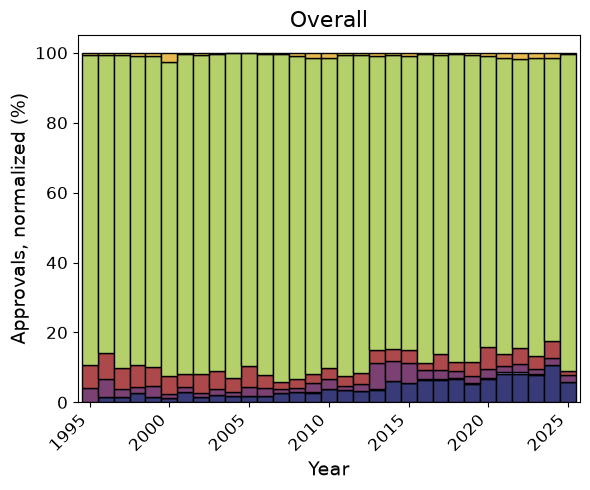

In [148]:
for k,v in DATASETS.items():
    if 'Decision_year' in v.columns:
        plot_drug_class_per_year(v, date_col='Decision_year', drug_class_colormap=drug_class_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Decision_year' column not found, skipping disease class per decision year plot.")

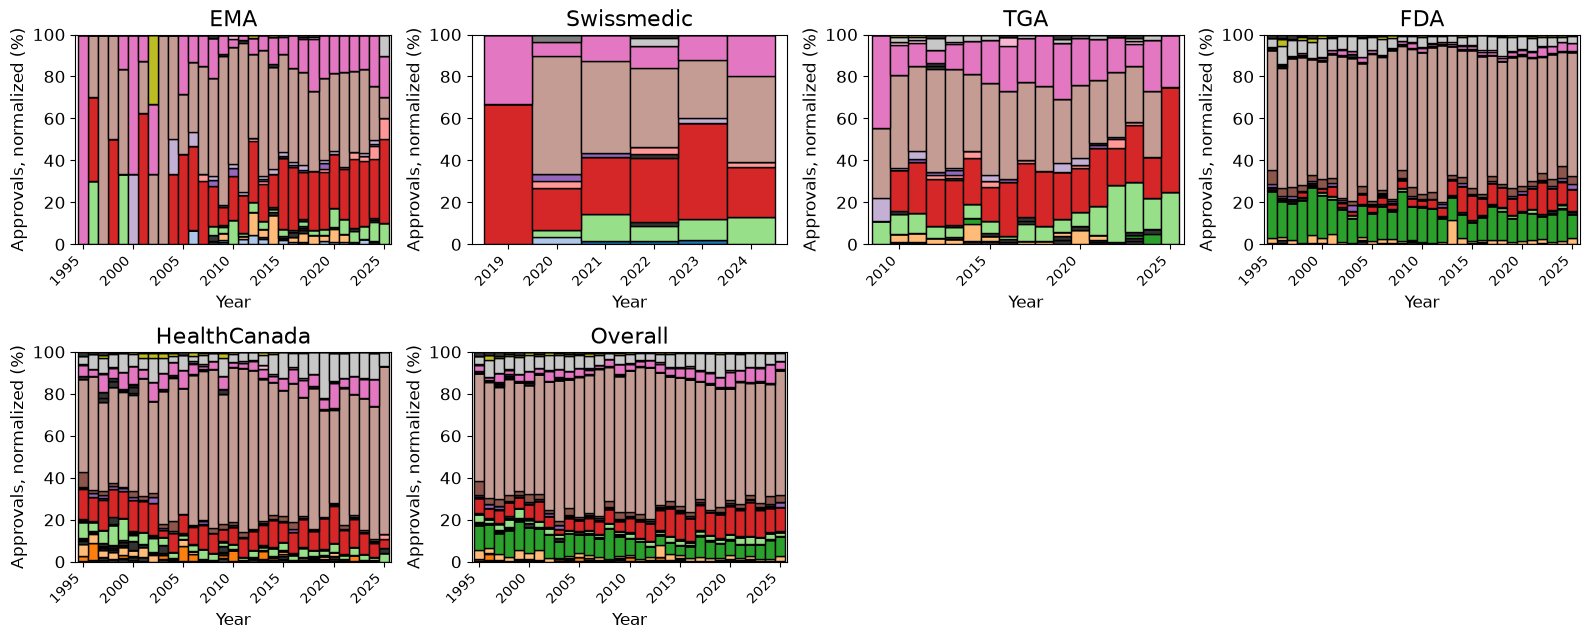

In [149]:
plot_some_class_per_year_panel(
    DATASETS, 
    bbox_to_anchor_val=(0.6, 0.2),
    date_col='Decision_year', 
    info_col="Administration_route",
    drug_class_colormap=admin_route_colormap,  # Changed from admin_route_cmap to admin_route_colormap
    nrows=3, 
    ncols=4,
    figsize_per_subplot=(4, 3)
)

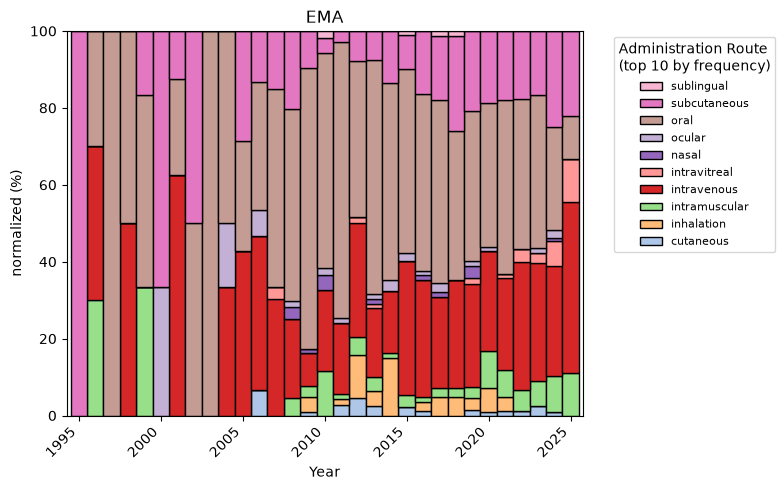

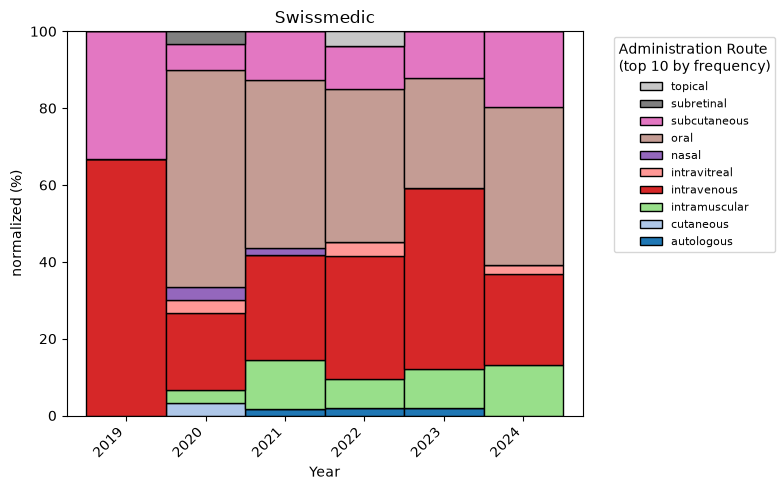

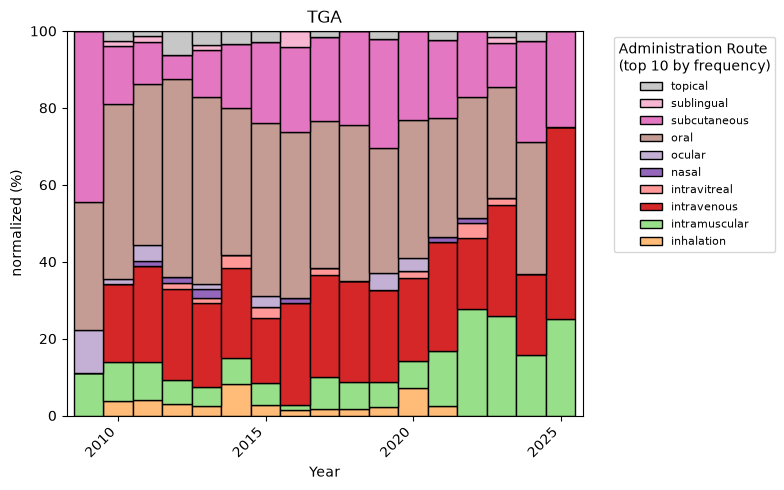

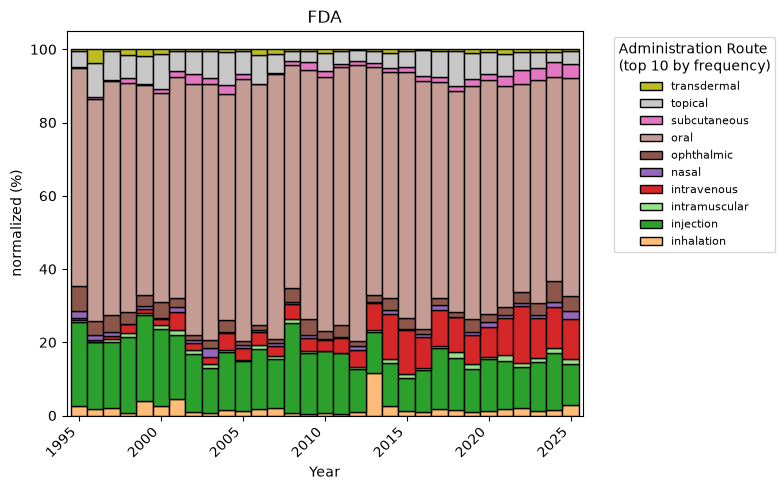

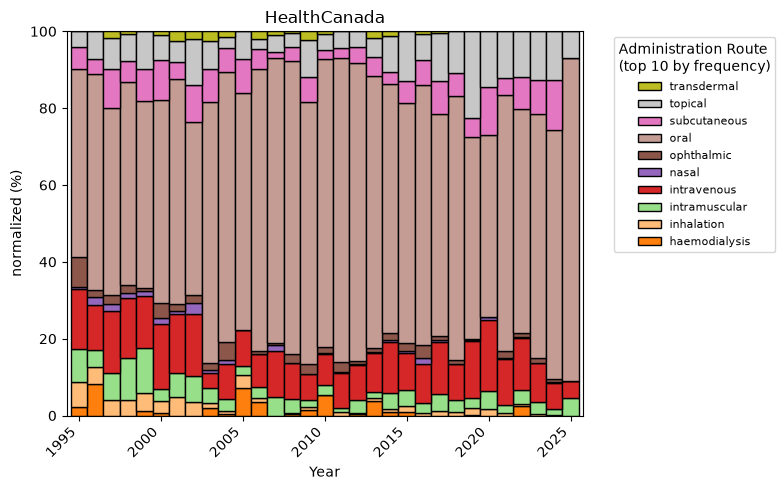

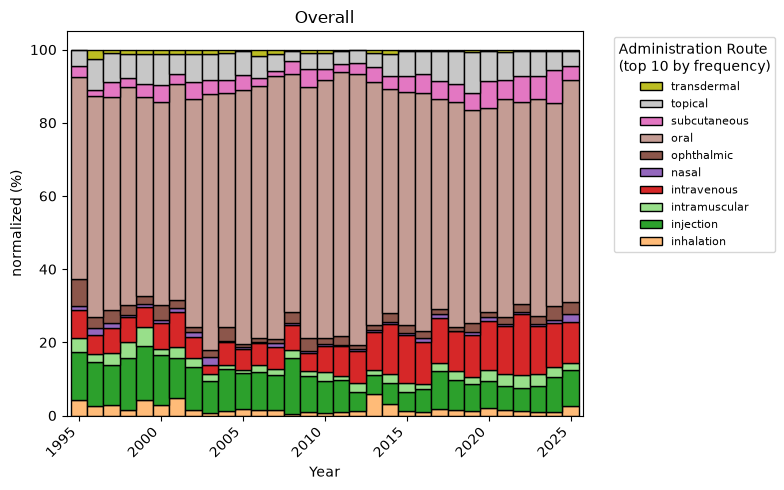

In [150]:
# Individual plots for Administration_route per year
for k,v in DATASETS.items():
    if 'Decision_year' in v.columns and 'Administration_route' in v.columns:
        plot_administration_route_per_year(v, agency_name=k, date_col='Decision_year', admin_route_colormap=admin_route_colormap, dataset_name=k)
    else:
        print(f"{k}: Required columns not found for administration route per year plot.")

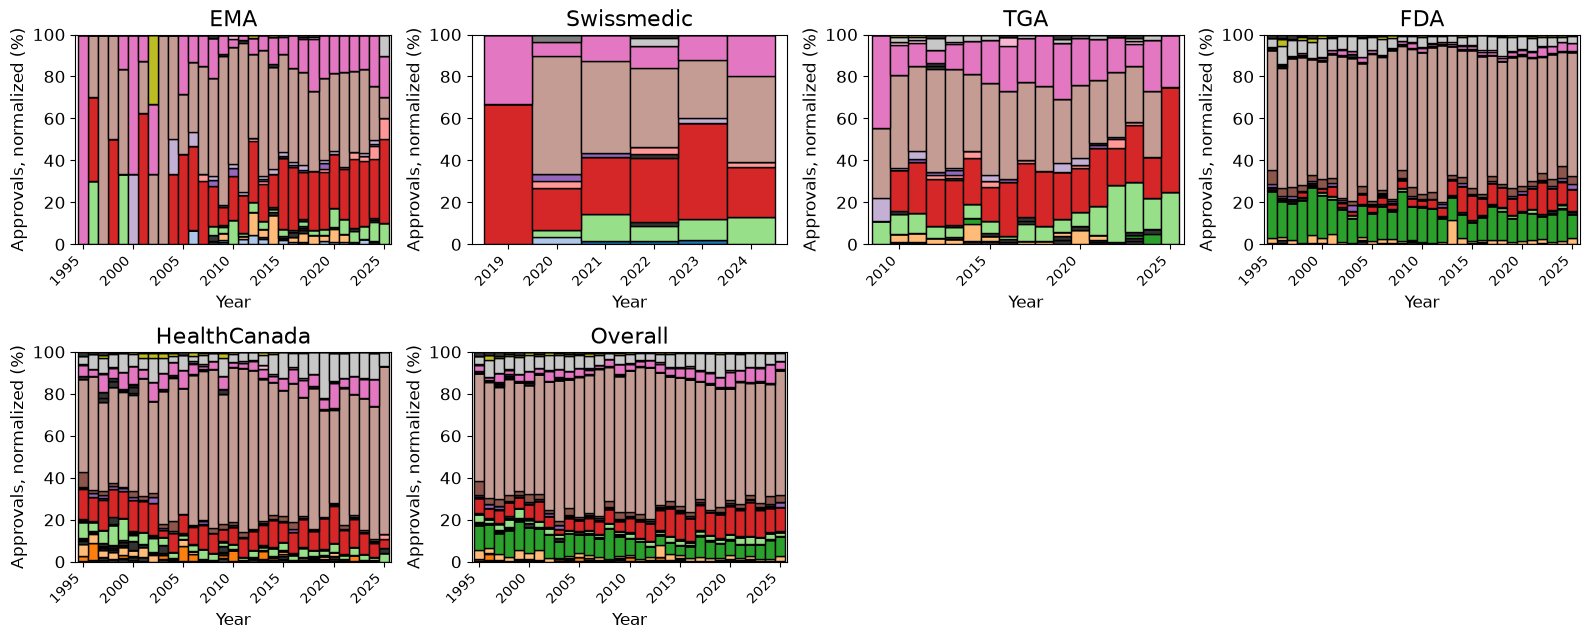

In [151]:
plot_some_class_per_year_panel(
    DATASETS, 
    bbox_to_anchor_val=(0.6, 0.2),
    date_col='Decision_year', 
    info_col="Administration_route",
    drug_class_colormap=admin_route_colormap, 
    nrows=3, 
    ncols=4,
    figsize_per_subplot=(4, 3)
)

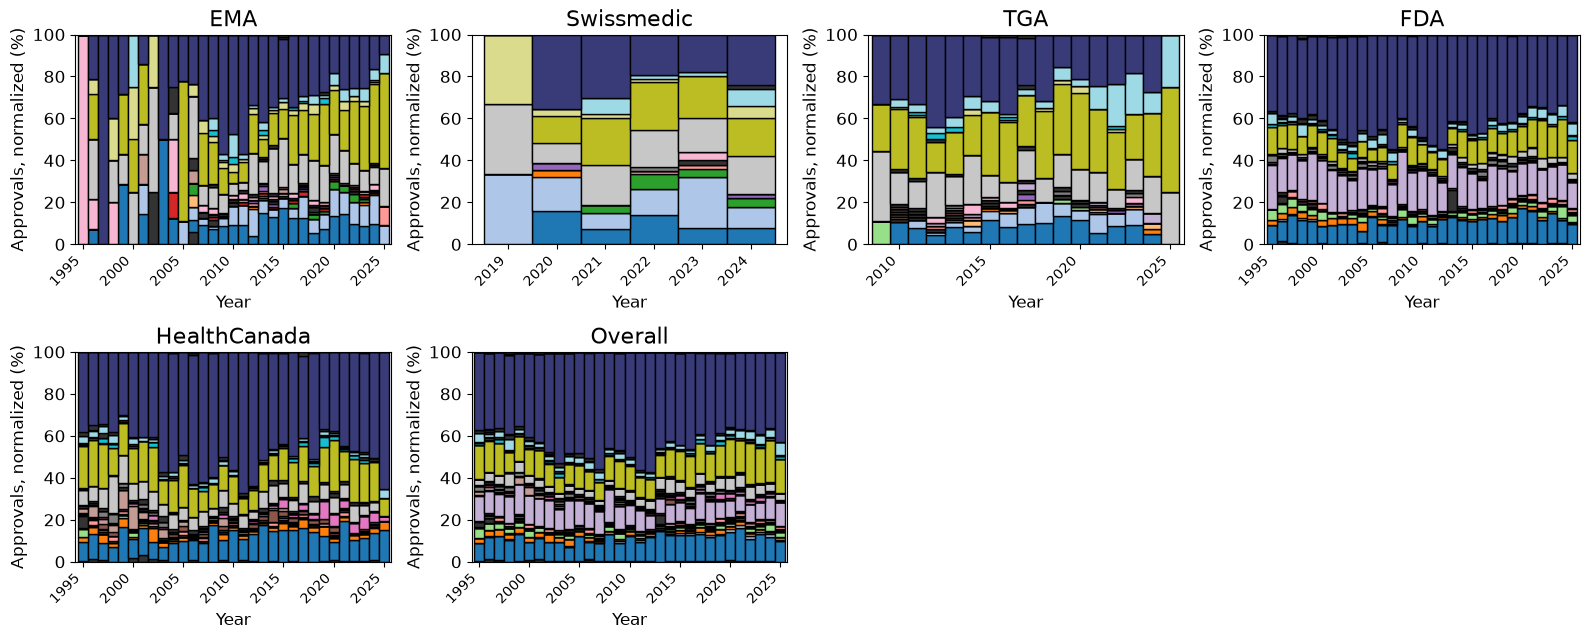

In [152]:
plot_some_class_per_year_panel(
    DATASETS, 
    bbox_to_anchor_val=(0.6, 0.15),
    date_col='Decision_year', 
    info_col="Pharmaceutical_form",
    drug_class_colormap=pharma_form_colormap, 
    nrows=3, 
    ncols=4,
    figsize_per_subplot=(4, 3)
)

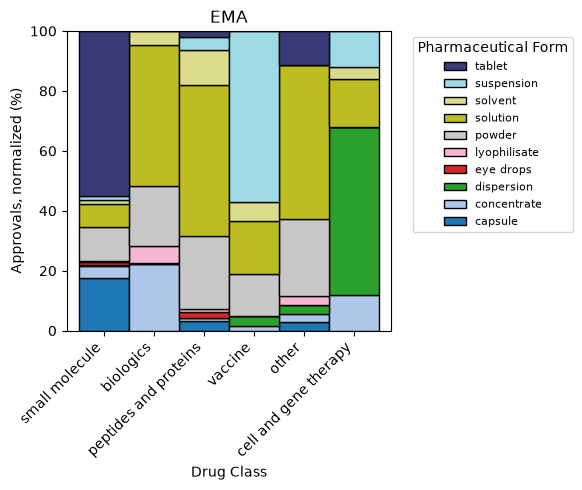

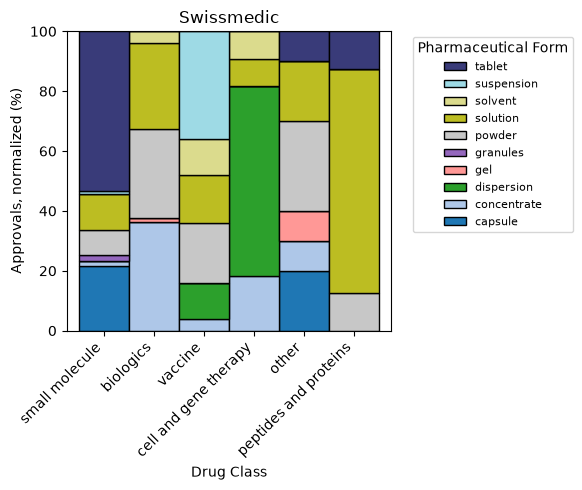

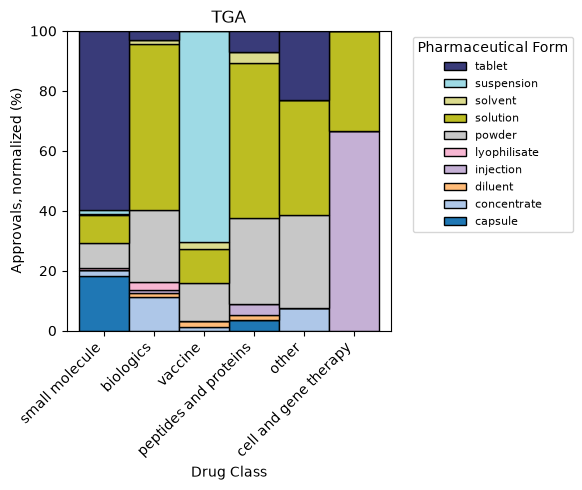

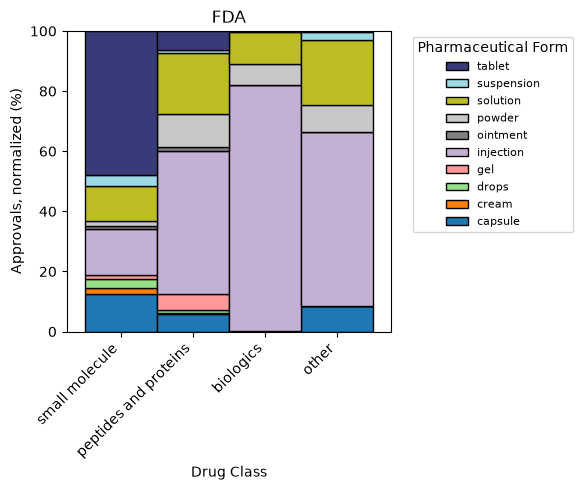

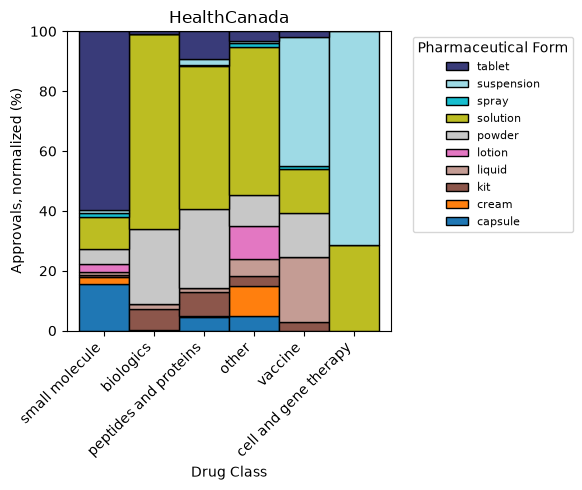

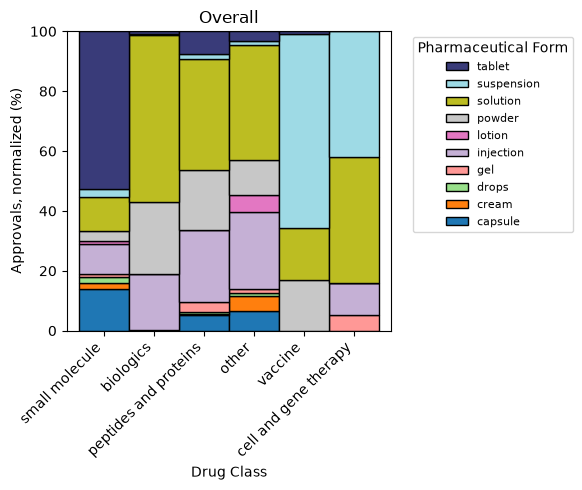

In [153]:
for k,v in DATASETS.items():
    if 'Pharmaceutical_form' in v.columns:
        plot_drug_class_by_pharmaceutical_form(v, pharma_form_colormap=pharma_form_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Pharmaceutical_form' column not found, skipping drug class by pharmaceutical form plot.")

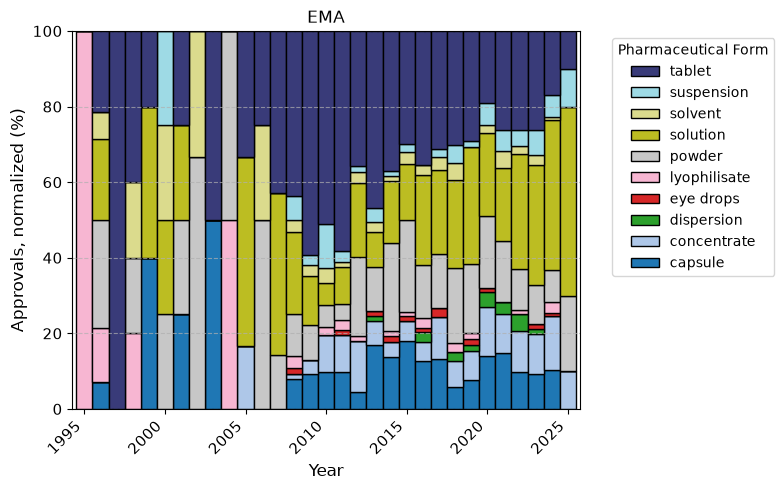

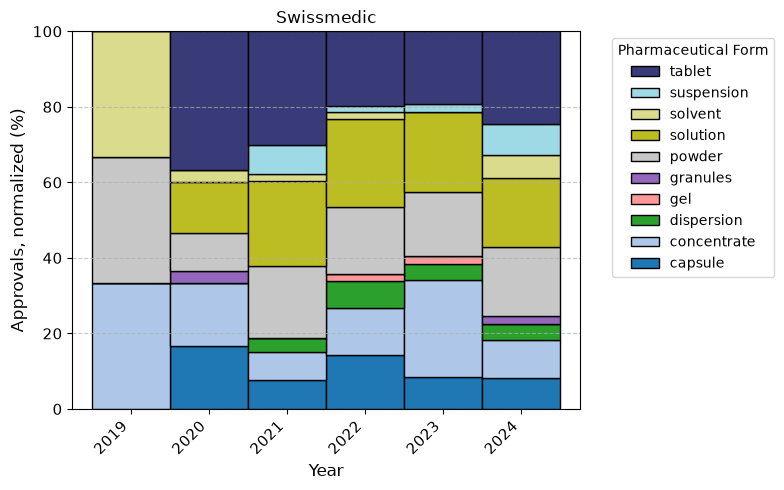

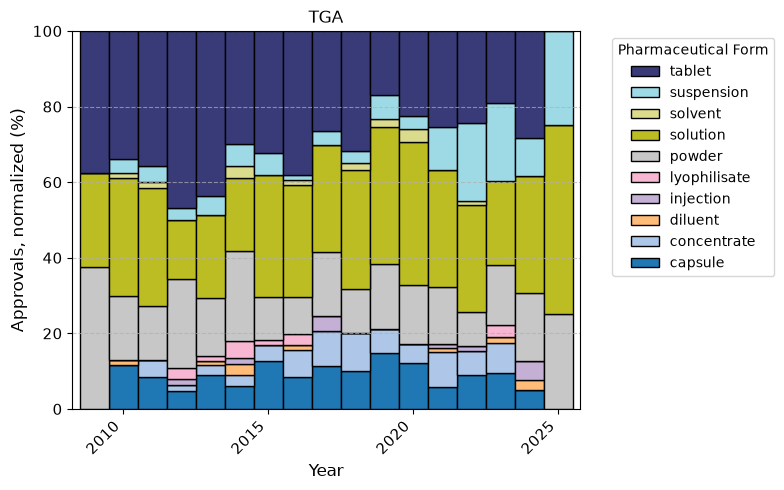

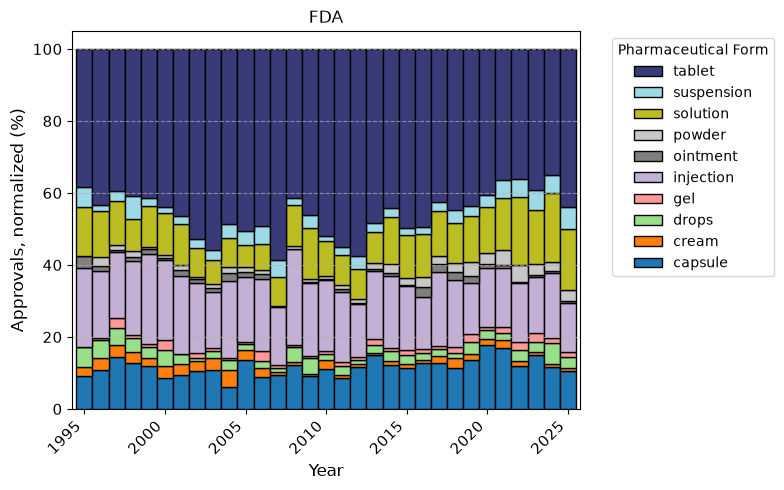

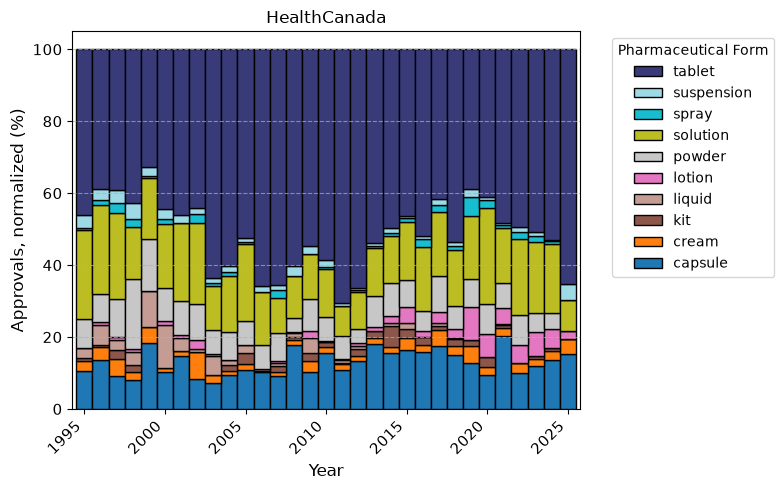

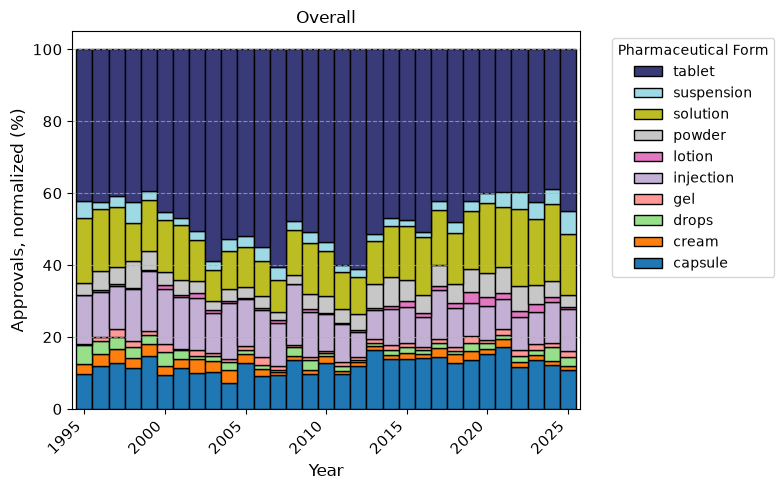

In [154]:
for k,v in DATASETS.items():
    if "Decision_date" in v.columns:
        plot_pharmaceutical_form_per_year(v, agency_name=k, date_col='Decision_date', pharma_form_colormap=pharma_form_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Decision_date' column not found, skipping pharmaceutical form per year plot.")


Top 2 Disease Classes (absolute Häufigkeit):
neoplasms: 422
diseases of the blood and blood-forming organs: 254

Top 2 Disease Classes (absolute Häufigkeit):
neoplasms: 72
diseases of the blood and blood-forming organs: 49

Top 2 Disease Classes (absolute Häufigkeit):
neoplasms: 268
infectious and parasitic diseases: 177

Top 2 Disease Classes (absolute Häufigkeit):
diseases of the nervous system: 540
infectious and parasitic diseases: 507

Top 2 Disease Classes (absolute Häufigkeit):
diseases of the circulatory system: 1920
diseases of the nervous system: 1466

Top 2 Disease Classes (absolute Häufigkeit):
diseases of the circulatory system: 2650
diseases of the nervous system: 2277


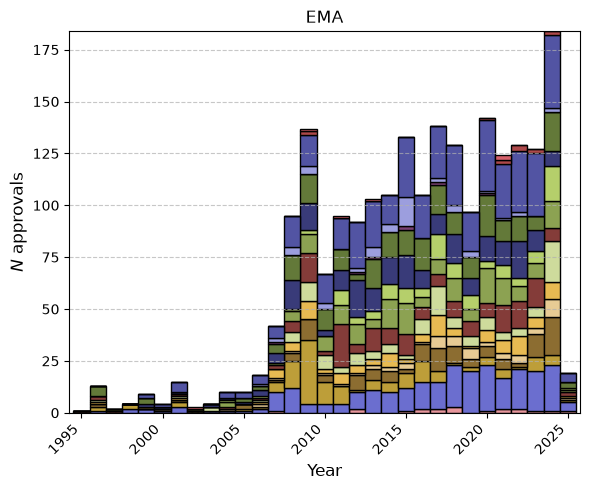

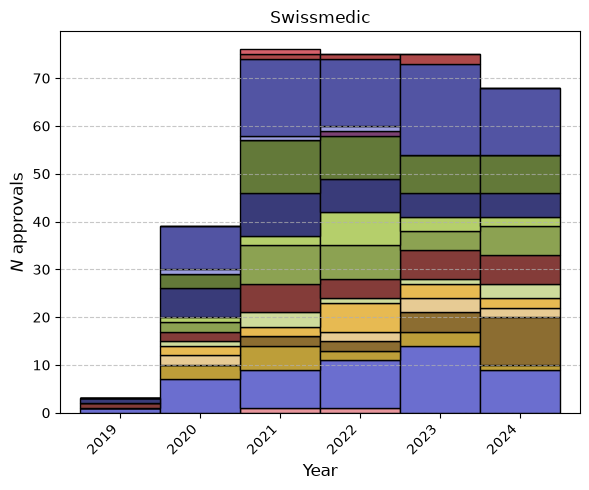

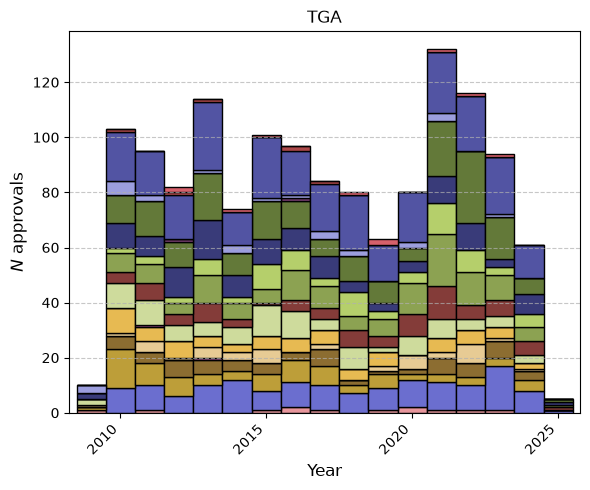

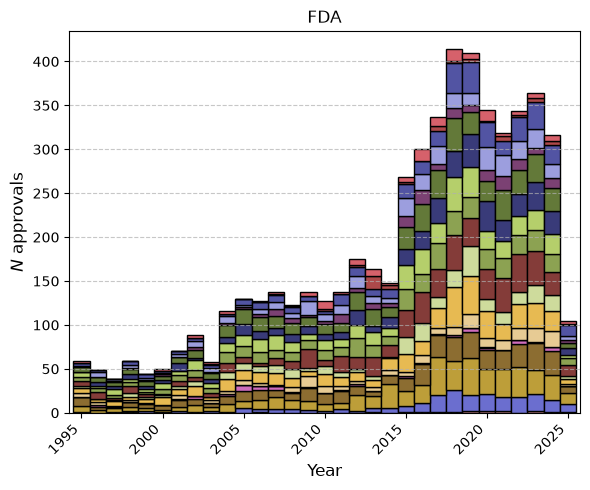

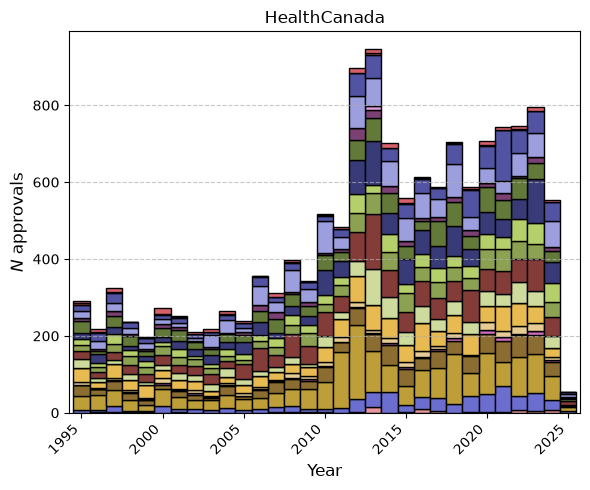

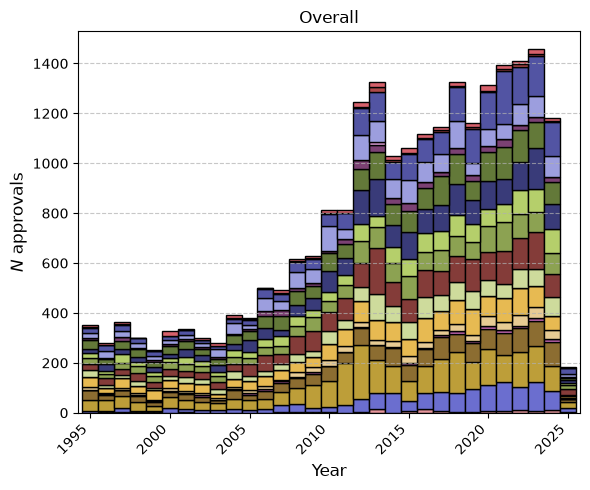

In [155]:
for k,v in DATASETS.items():
    if 'Decision_year' in v.columns and 'Disease_class(es)' in v.columns:
        plot_disease_class_per_decision_year_absolute(v, year_col='Decision_year', disease_class_colormap=disease_class_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Decision_year' or 'Disease_class(es)' column not found, skipping disease class per decision year absolute plot.")

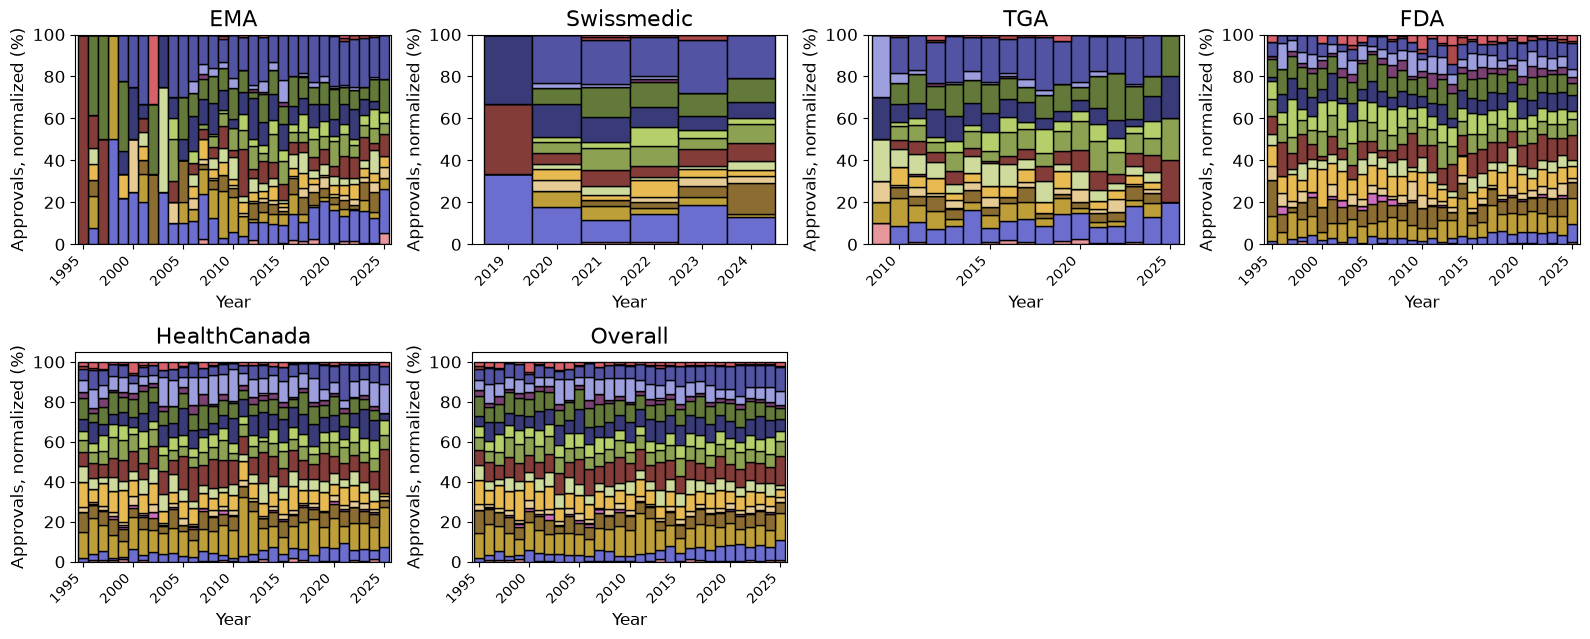

In [156]:
plot_some_class_per_year_panel(
    DATASETS, 
    bbox_to_anchor_val=(0.4, 0.2),
    date_col='Decision_year', 
    info_col="Disease_class(es)",
    drug_class_colormap=disease_class_colormap, 
    nrows=3, 
    ncols=4,
    figsize_per_subplot=(4, 3)
)

In [157]:
# Individual plots for Disease_class(es) per year
for k,v in DATASETS.items():
    if 'Decision_year' in v.columns and 'Disease_class(es)' in v.columns:
        plot_some_class_per_year_single(
            v, 
            dataset_name=k,
            date_col='Decision_year', 
            info_col='Disease_class(es)',
            drug_class_colormap=disease_class_colormap,
            bbox_to_anchor_val=(1.05, 1)
        )
    else:
        print(f"{k}: Required columns not found for disease class per year plot.")

Original length: 1491, Final length after cleaning: 1491, Percentage kept: 100.00%
Original length: 233, Final length after cleaning: 233, Percentage kept: 100.00%
Original length: 988, Final length after cleaning: 988, Percentage kept: 100.00%
Original length: 3088, Final length after cleaning: 3088, Percentage kept: 100.00%
Original length: 8046, Final length after cleaning: 8046, Percentage kept: 100.00%
Original length: 13846, Final length after cleaning: 13846, Percentage kept: 100.00%


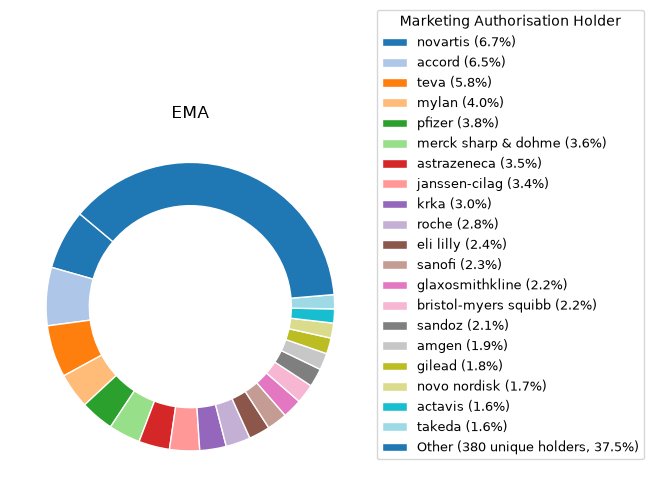

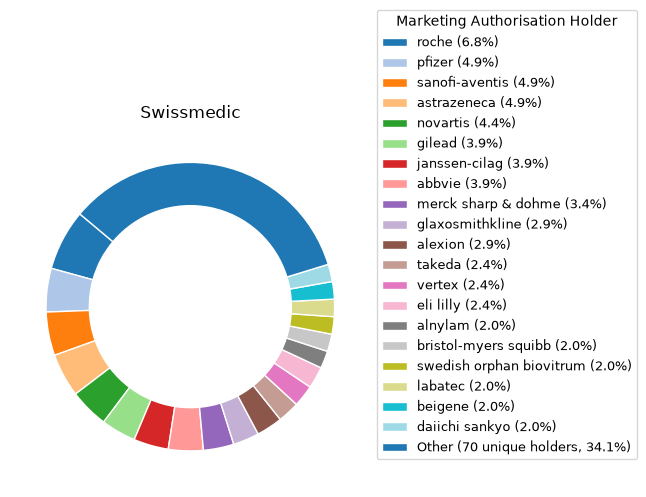

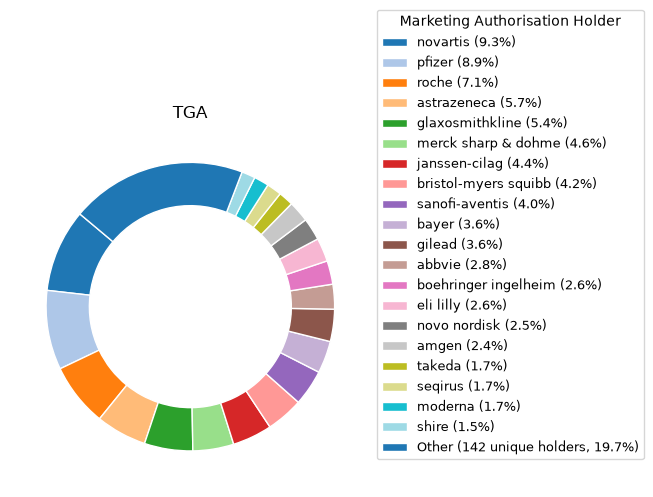

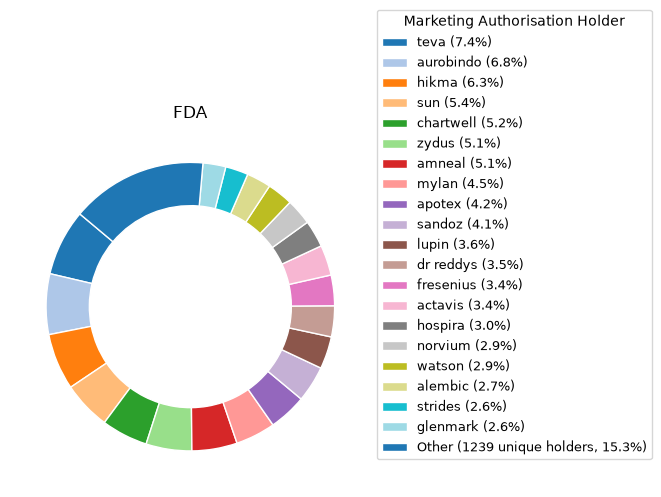

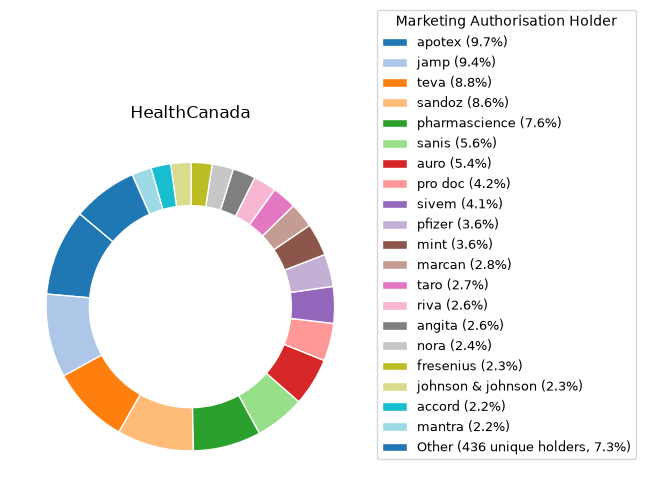

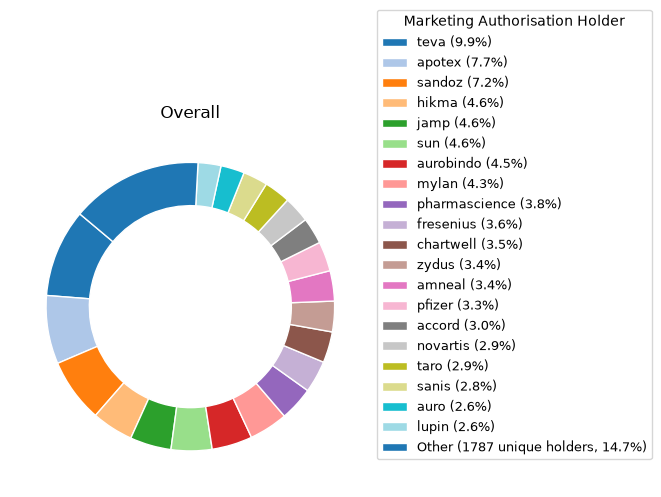

In [158]:
for k,v in DATASETS.items():
    if 'Marketing_authorisation_holder_extracted' in v.columns:
        plot_marketing_holder_distribution_pie(v, data_col='Marketing_authorisation_holder_extracted', dataset_name=k)
    else:
        if 'Marketing_authorisation_holder' in v.columns:
            plot_marketing_holder_distribution_pie(v, data_col='Marketing_authorisation_holder', dataset_name=k)
        else:
            print(f"{k}: 'Marketing_authorisation_holder' column not found, skipping marketing holder distribution pie chart.")
            continue

In [159]:
# Export marketing authorization holders for each agency
def sort_by_name(df, col_name):
    df = df.copy()
    df[col_name] = df[col_name].str.lower().str.strip()
    return df.sort_values(by=col_name)

# Process each agency in Overall dataset
for agency in [
                'EMA', 
                # 'PMDA', 
                'Swissmedic', 
                'TGA', 
                'FDA', 
                'HealthCanada'
                ]:
    agency_df = get_agency_data(agency)
    
    if 'Marketing_authorisation_holder' in agency_df.columns:
        sorted_df = sort_by_name(agency_df, 'Marketing_authorisation_holder')
        unique_holders = sorted_df['Marketing_authorisation_holder'].dropna().unique()
        
        # Save to file
        filename = f"{SAVE_DIR}/{agency}_marketing_authorisation_holders.txt"
        with open(filename, 'w', encoding="utf-8") as f:
            for holder in unique_holders:
                f.write(f"{holder}\n")
        print(f"Saved {len(unique_holders)} unique holders for {agency} to {filename}")
    else:
        print(f"{agency}: No Marketing_authorisation_holder column found")


Saved 584 unique holders for EMA to /Users/shtosti/Dropbox/Projects/DrugFork/analysis/1995/approved/EMA_marketing_authorisation_holders.txt
Saved 94 unique holders for Swissmedic to /Users/shtosti/Dropbox/Projects/DrugFork/analysis/1995/approved/Swissmedic_marketing_authorisation_holders.txt
Saved 248 unique holders for TGA to /Users/shtosti/Dropbox/Projects/DrugFork/analysis/1995/approved/TGA_marketing_authorisation_holders.txt
Saved 1881 unique holders for FDA to /Users/shtosti/Dropbox/Projects/DrugFork/analysis/1995/approved/FDA_marketing_authorisation_holders.txt
Saved 495 unique holders for HealthCanada to /Users/shtosti/Dropbox/Projects/DrugFork/analysis/1995/approved/HealthCanada_marketing_authorisation_holders.txt


/Users/shtosti/Dropbox/Projects/DrugFork/src/analysis/analysis_utils.py:819: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=combined_df, y='Agency', x='Review_duration_days', palette='tab20', orient='h')


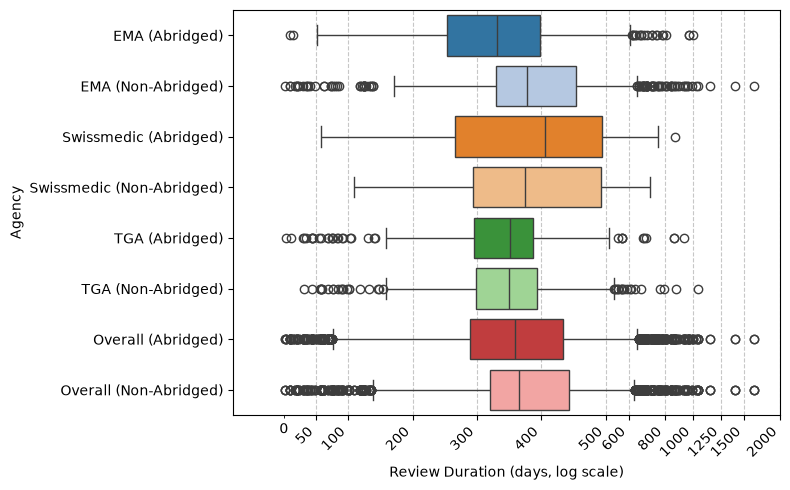

In [160]:
plot_review_duration_by_agency(
    agency_dfs=DATASETS,
    submission_col='Application_date',
    decision_col='Decision_date',
    dataset_name='combined'
)

/Users/shtosti/Dropbox/Projects/DrugFork/src/analysis/analysis_utils.py:891: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
/Users/shtosti/Dropbox/Projects/DrugFork/src/analysis/analysis_utils.py:891: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
/Users/shtosti/Dropbox/Projects/DrugFork/src/analysis/analysis_utils.py:891: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_durat

FDA: No valid review duration data (empty after filtering). Skipping plot.
HealthCanada: No valid review duration data (empty after filtering). Skipping plot.


/Users/shtosti/Dropbox/Projects/DrugFork/src/analysis/analysis_utils.py:891: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',


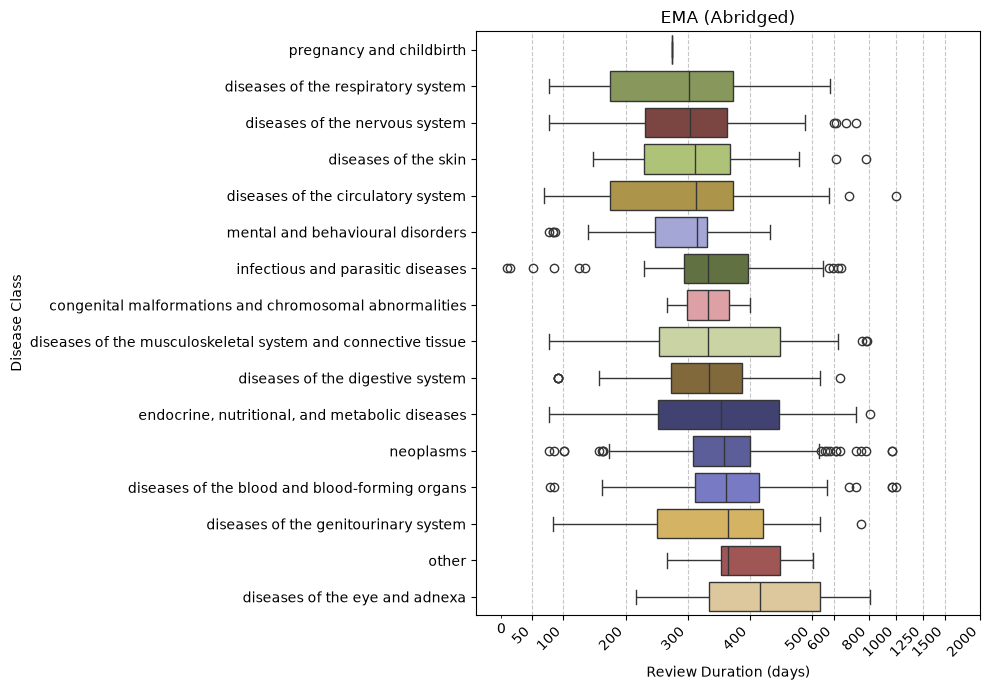

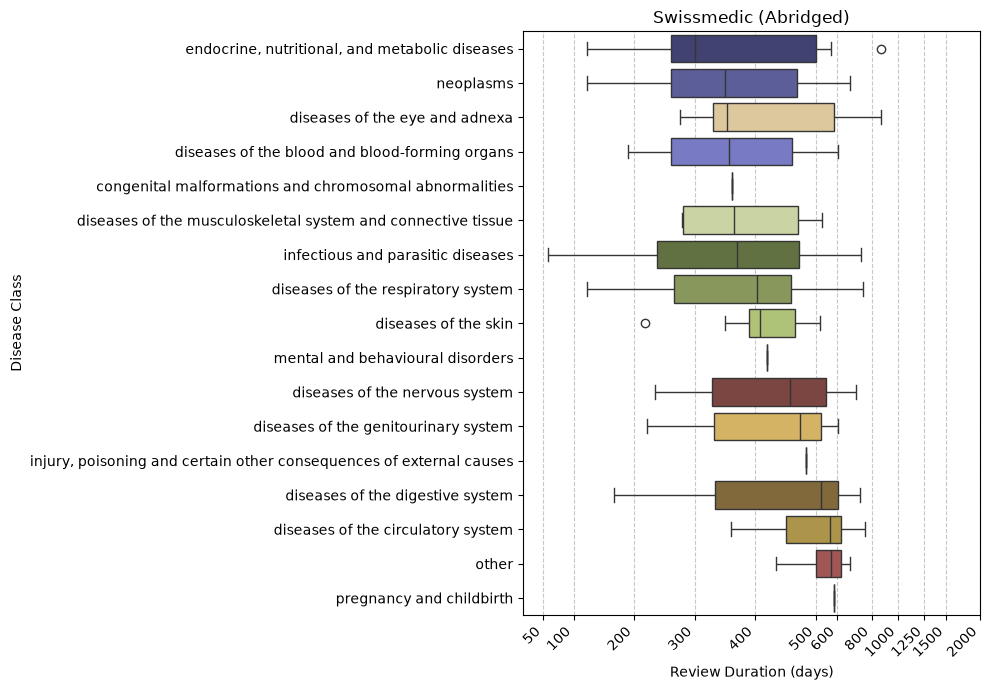

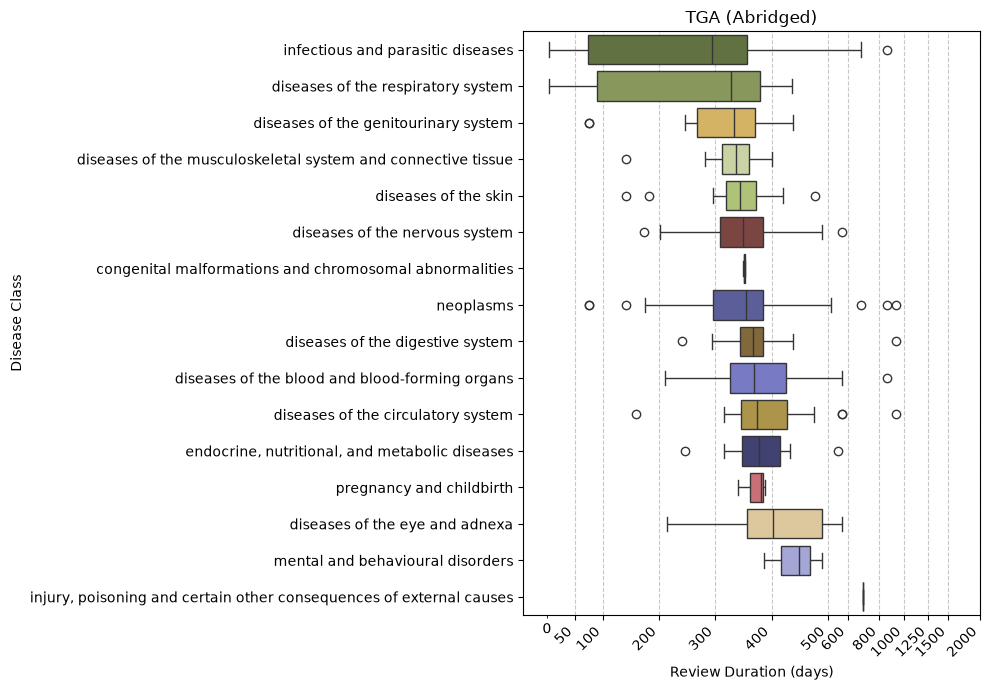

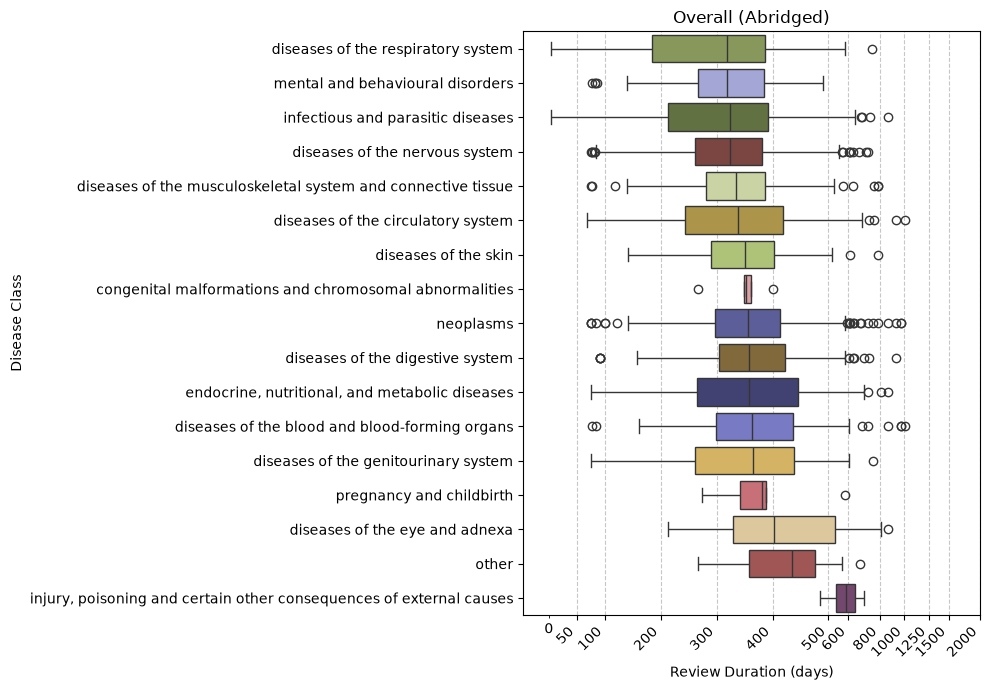

In [161]:
for k,v in DATASETS.items():
    if 'Application_date' in v.columns and 'Decision_date' in v.columns:
        plot_review_duration_by_disease_class(
            v,
            submission_col='Application_date',
            decision_col='Decision_date',
            dataset_name=k,
            disease_class_colormap=disease_class_colormap,
            abridged=True
        )
    else:
        print(f"{k}: 'Application_date' or 'Decision_date' column not found, skipping review duration by agency plot.")

/Users/shtosti/Dropbox/Projects/DrugFork/src/analysis/analysis_utils.py:891: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
/Users/shtosti/Dropbox/Projects/DrugFork/src/analysis/analysis_utils.py:891: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
/Users/shtosti/Dropbox/Projects/DrugFork/src/analysis/analysis_utils.py:891: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_durat

FDA: No valid review duration data (empty after filtering). Skipping plot.
HealthCanada: No valid review duration data (empty after filtering). Skipping plot.


/Users/shtosti/Dropbox/Projects/DrugFork/src/analysis/analysis_utils.py:891: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',


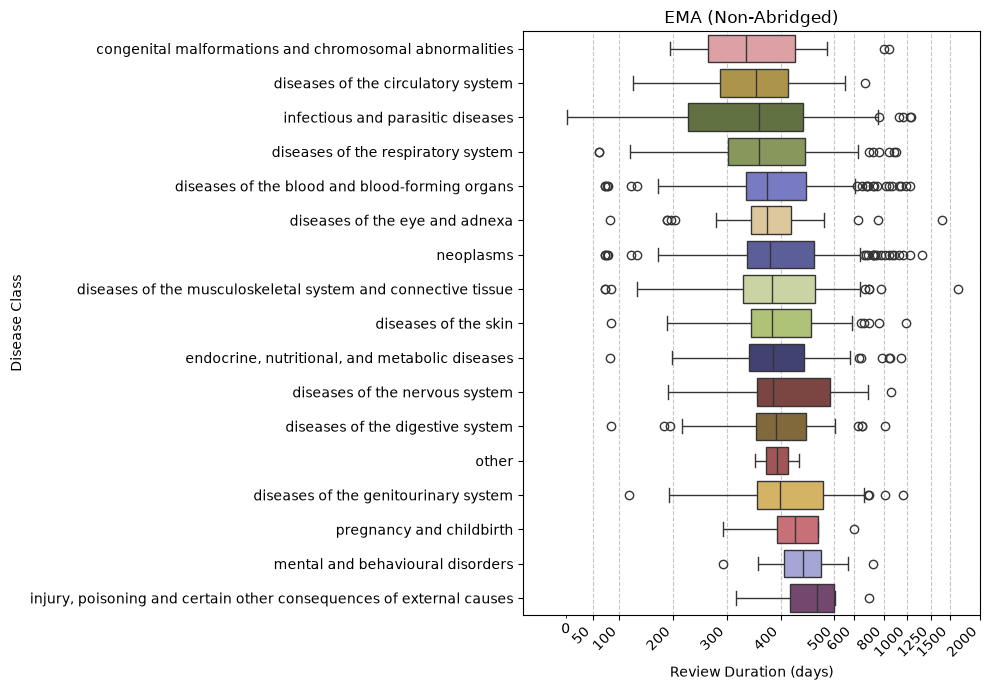

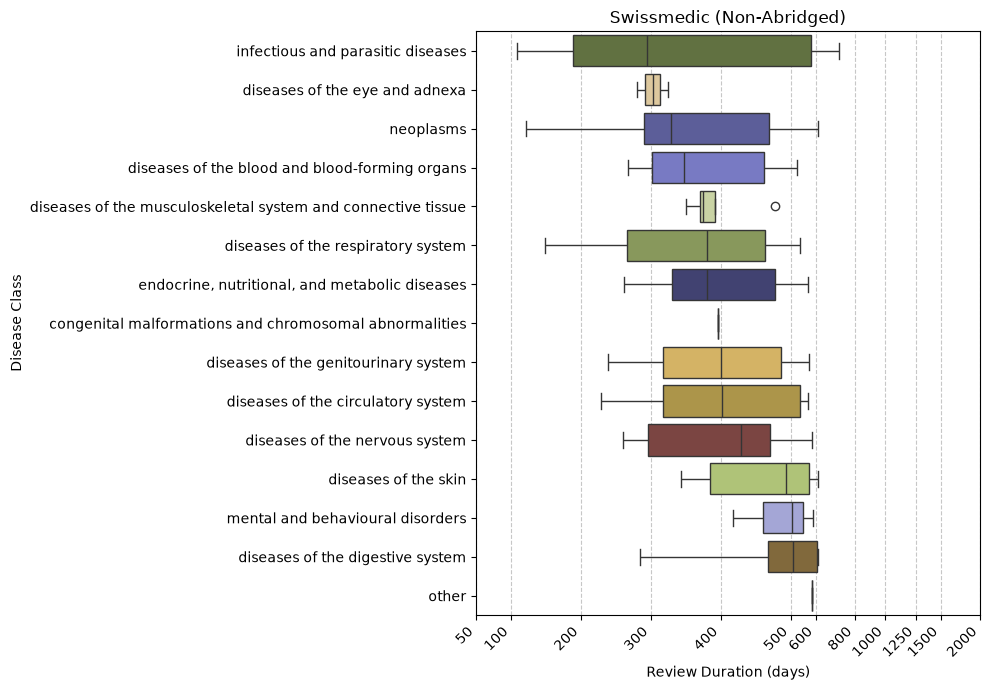

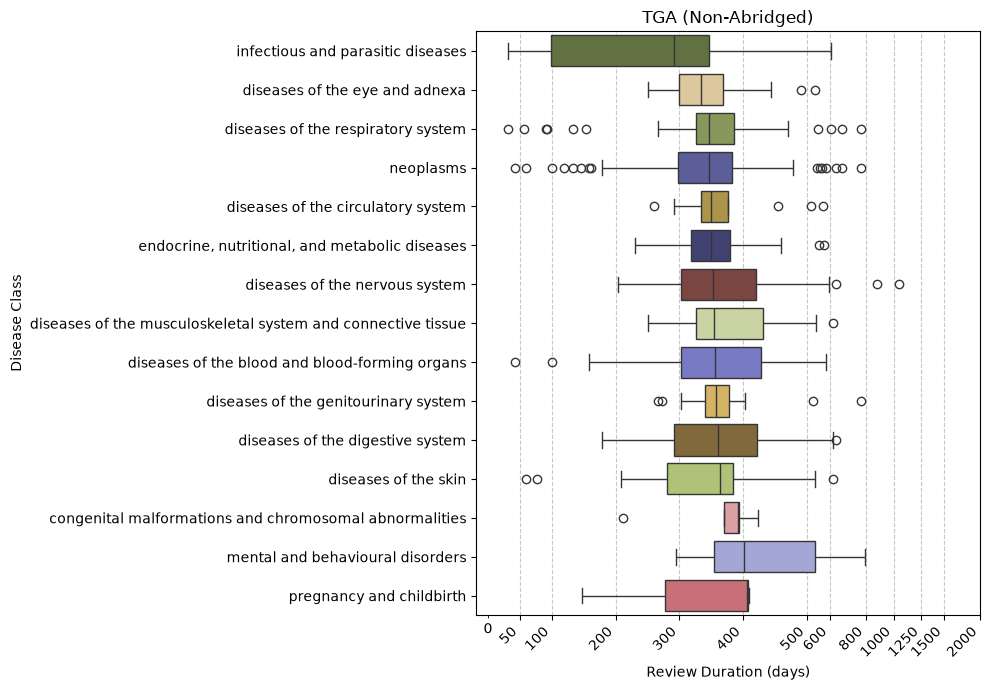

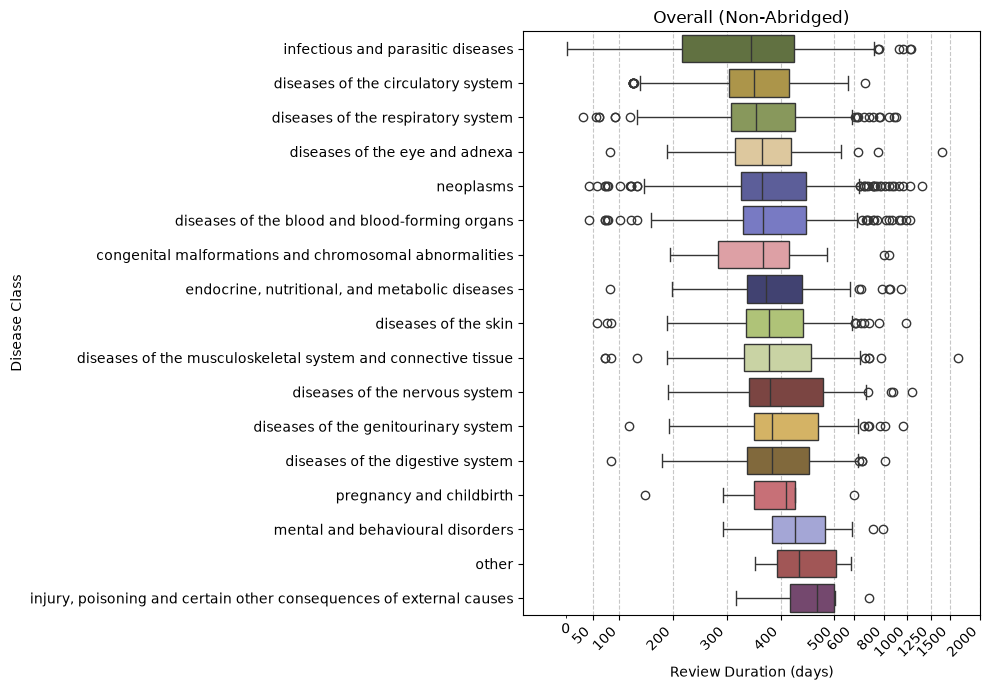

In [162]:
for k,v in DATASETS.items():
    if 'Application_date' in v.columns and 'Decision_date' in v.columns:
        plot_review_duration_by_disease_class(
            v,
            submission_col='Application_date',
            decision_col='Decision_date',
            dataset_name=k,
            disease_class_colormap=disease_class_colormap,
            abridged=False
        )
    else:
        print(f"{k}: 'Application_date' or 'Decision_date' column not found, skipping review duration by agency plot.")

/Users/shtosti/Dropbox/Projects/DrugFork/src/analysis/analysis_utils.py:891: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
/Users/shtosti/Dropbox/Projects/DrugFork/src/analysis/analysis_utils.py:891: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
/Users/shtosti/Dropbox/Projects/DrugFork/src/analysis/analysis_utils.py:891: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_durat

FDA: No valid review duration data (empty after filtering). Skipping plot.
HealthCanada: No valid review duration data (empty after filtering). Skipping plot.


/Users/shtosti/Dropbox/Projects/DrugFork/src/analysis/analysis_utils.py:891: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',


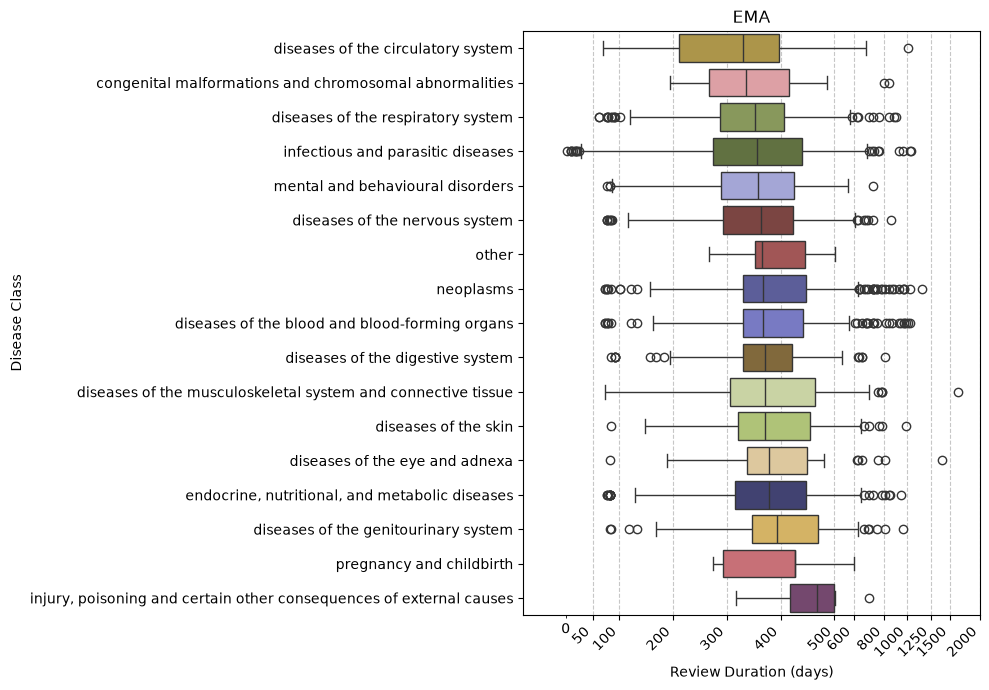

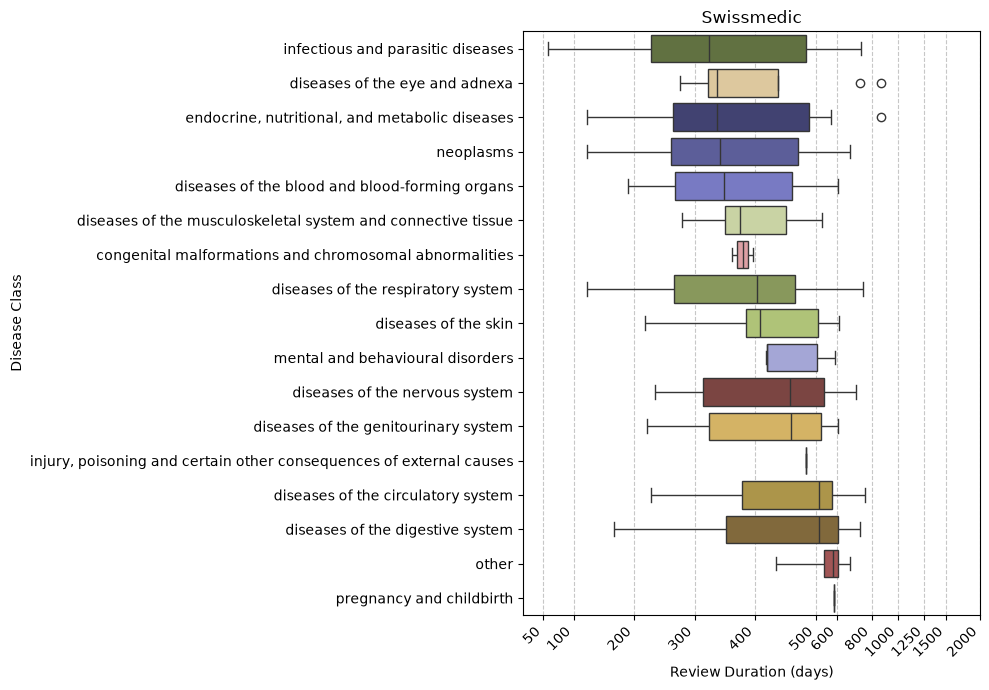

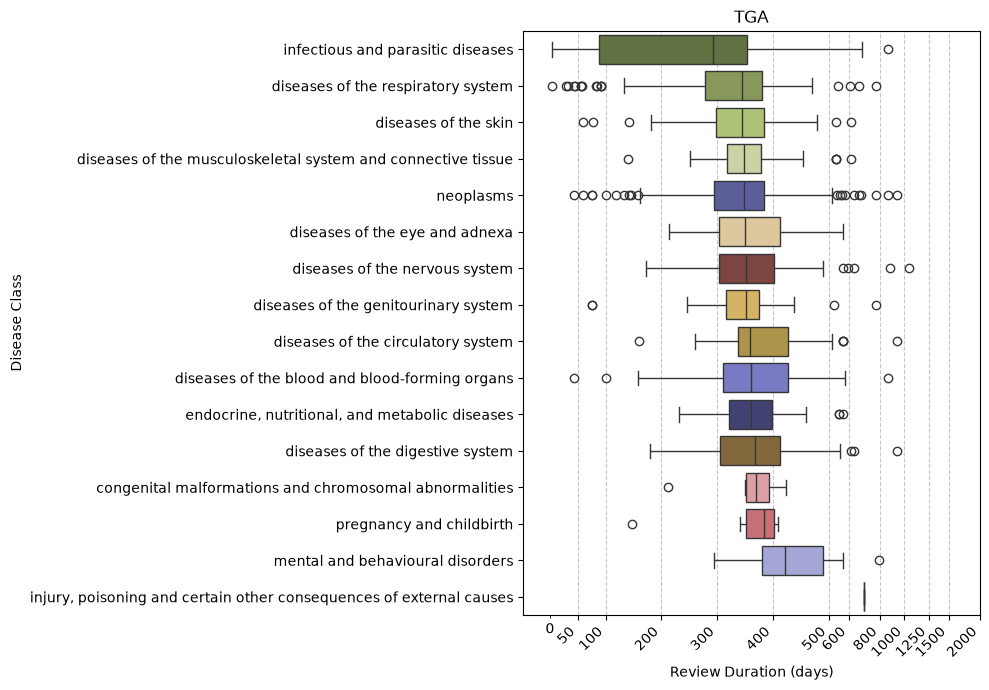

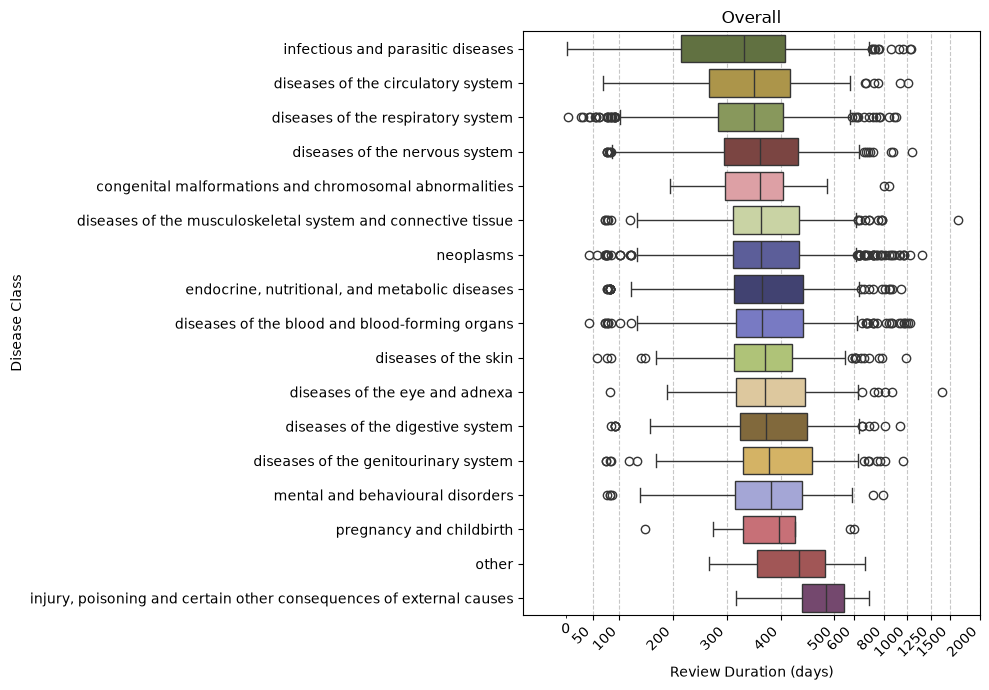

In [163]:
for k,v in DATASETS.items():
    if 'Application_date' in v.columns and 'Decision_date' in v.columns:
        plot_review_duration_by_disease_class(
            v,
            submission_col='Application_date',
            decision_col='Decision_date',
            dataset_name=k,
            disease_class_colormap=disease_class_colormap,
            abridged=None
        )
    else:
        print(f"{k}: 'Application_date' or 'Decision_date' column not found, skipping review duration by agency plot.")

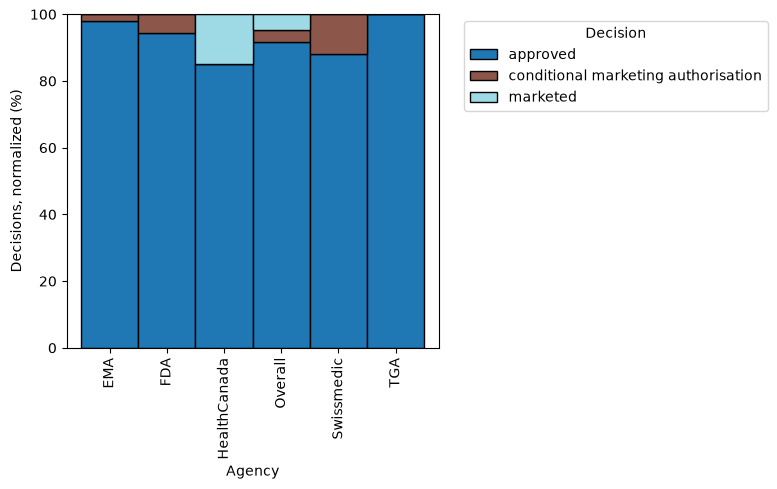

In [164]:
plot_decision_distribution_by_agency(
    agency_dfs=DATASETS,
    dataset_name='combined'
)

In [165]:
print(DATASETS['Overall']['Decision'].value_counts())

Decision
approved                               28921
marketed                                1519
conditional marketing authorisation     1116
Name: count, dtype: int64


In [166]:
for agency, df in DATASETS.items():
    if 'Decision' in df.columns:
        print(f"\n{agency}:")
        print(df['Decision'].unique()[:20])


EMA:
<StringArray>
['approved', 'conditional marketing authorisation']
Length: 2, dtype: str

Swissmedic:
<StringArray>
['approved', 'conditional marketing authorisation']
Length: 2, dtype: str

TGA:
<StringArray>
['approved']
Length: 1, dtype: str

FDA:
<StringArray>
['approved', 'conditional marketing authorisation']
Length: 2, dtype: str

HealthCanada:
<StringArray>
['approved', 'marketed']
Length: 2, dtype: str

Overall:
<StringArray>
['approved', 'conditional marketing authorisation', 'marketed']
Length: 3, dtype: str


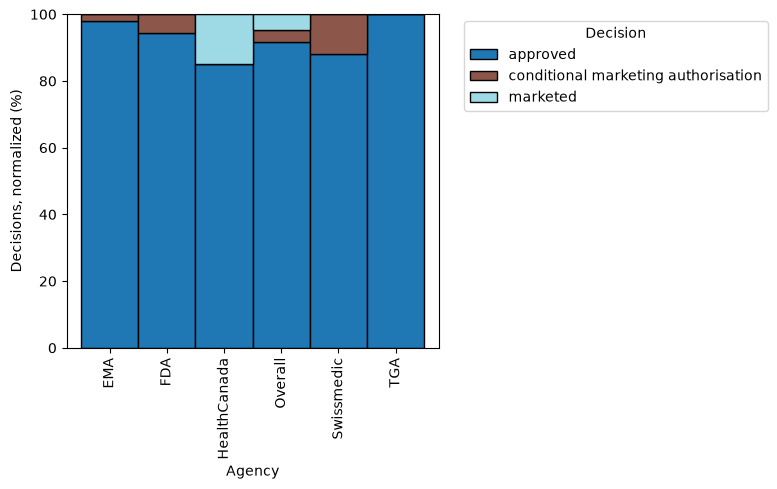

In [167]:
plot_decision_distribution_by_agency(
    DATASETS,
    dataset_name='combined'
)

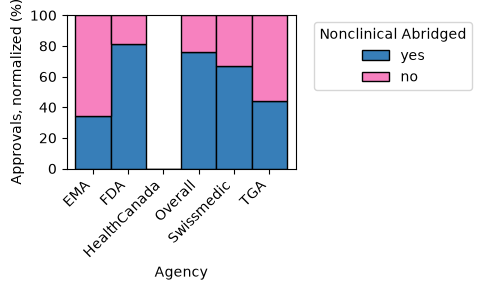

In [168]:
plot_nonclinical_abridged_distribution(
    agency_dfs=DATASETS,
    dataset_name='combined'
)

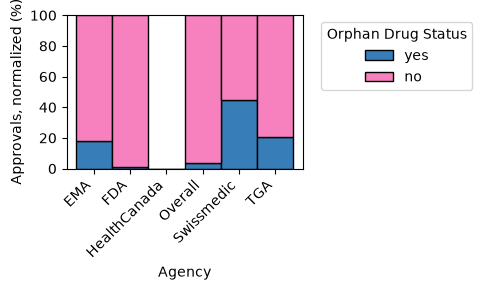

In [169]:
plot_orphan_drug_status_distribution(
    agency_dfs=DATASETS,
    dataset_name='combined'
)

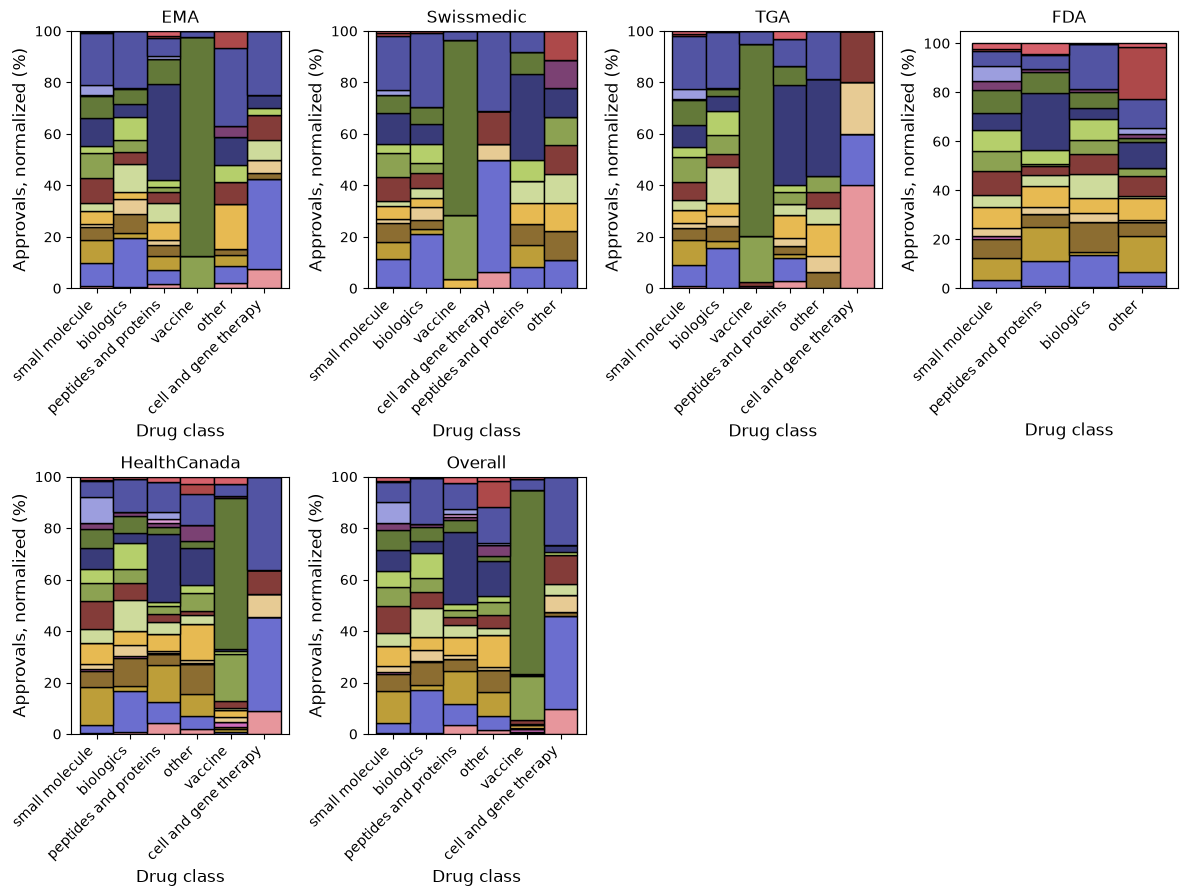

In [170]:
# Panel plot for disease class per drug class
plot_disease_class_per_drug_class_panel(
    DATASETS, 
    xcol='Drug_class',
    ycol="Disease_class(es)",
    disease_class_colormap=disease_class_colormap, 
    nrows=3, 
    ncols=4,
    figsize_per_subplot=(3, 4)
)

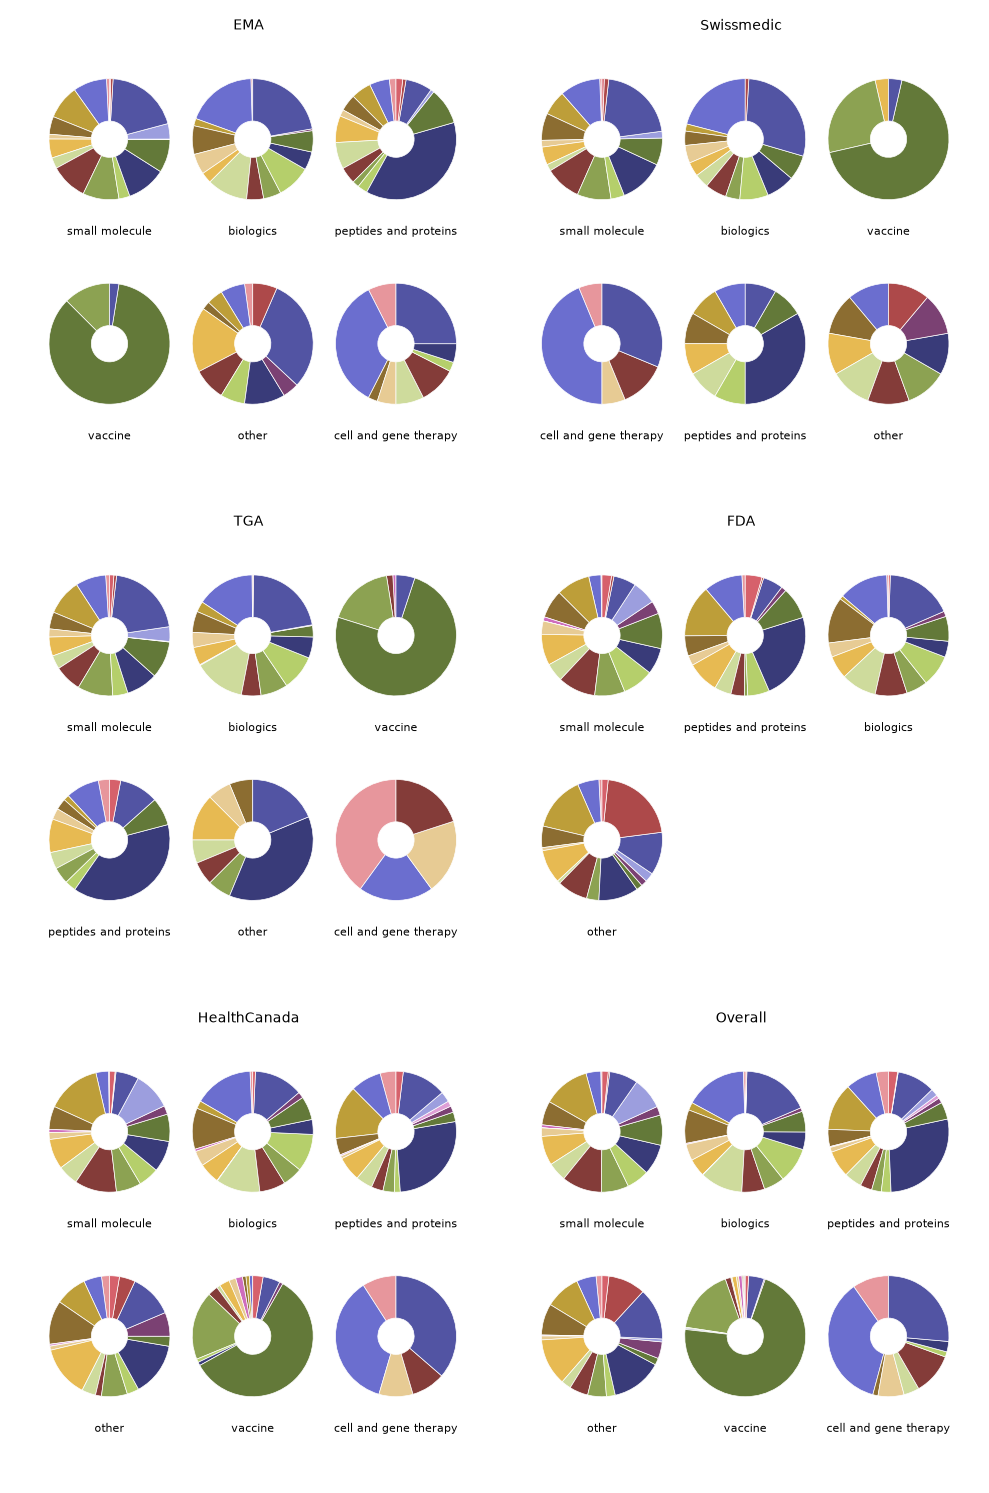

In [171]:
# Panel plot for disease class per drug class
plot_pie_disease_class_per_drug_class_panel(
    DATASETS, 
    xcol='Drug_class',
    ycol="Disease_class(es)",
    disease_class_colormap=disease_class_colormap, 
    nrows=4, 
    ncols=2,
    figsize_per_subplot=(5, 5)
)

# Burden

In [172]:
# Load preprocessed burden data
# Note: Run 'python src/burden_mapping/preprocess_burden_data.py' first if the data doesn't exist
burden_deaths = load_burden_data("Deaths")
burden_prevalence = load_burden_data("Prevalence")
burden_incidence = load_burden_data("Incidence")

Loaded burden data: 435 records, 15 disease classes
  Year range: 1995 - 2023
Loaded burden data: 435 records, 15 disease classes
  Year range: 1995 - 2023
Loaded burden data: 435 records, 15 disease classes
  Year range: 1995 - 2023


Processing datasets...
  - EMA
  - Swissmedic
  - TGA
  - FDA
  - HealthCanada
  - Overall
Found 12 disease classes
Year range: 1995 - 2025

Saved: /Users/shtosti/Dropbox/Projects/DrugFork/analysis/1995/approved/burden/deaths_vs_approvals_Decision_year.png


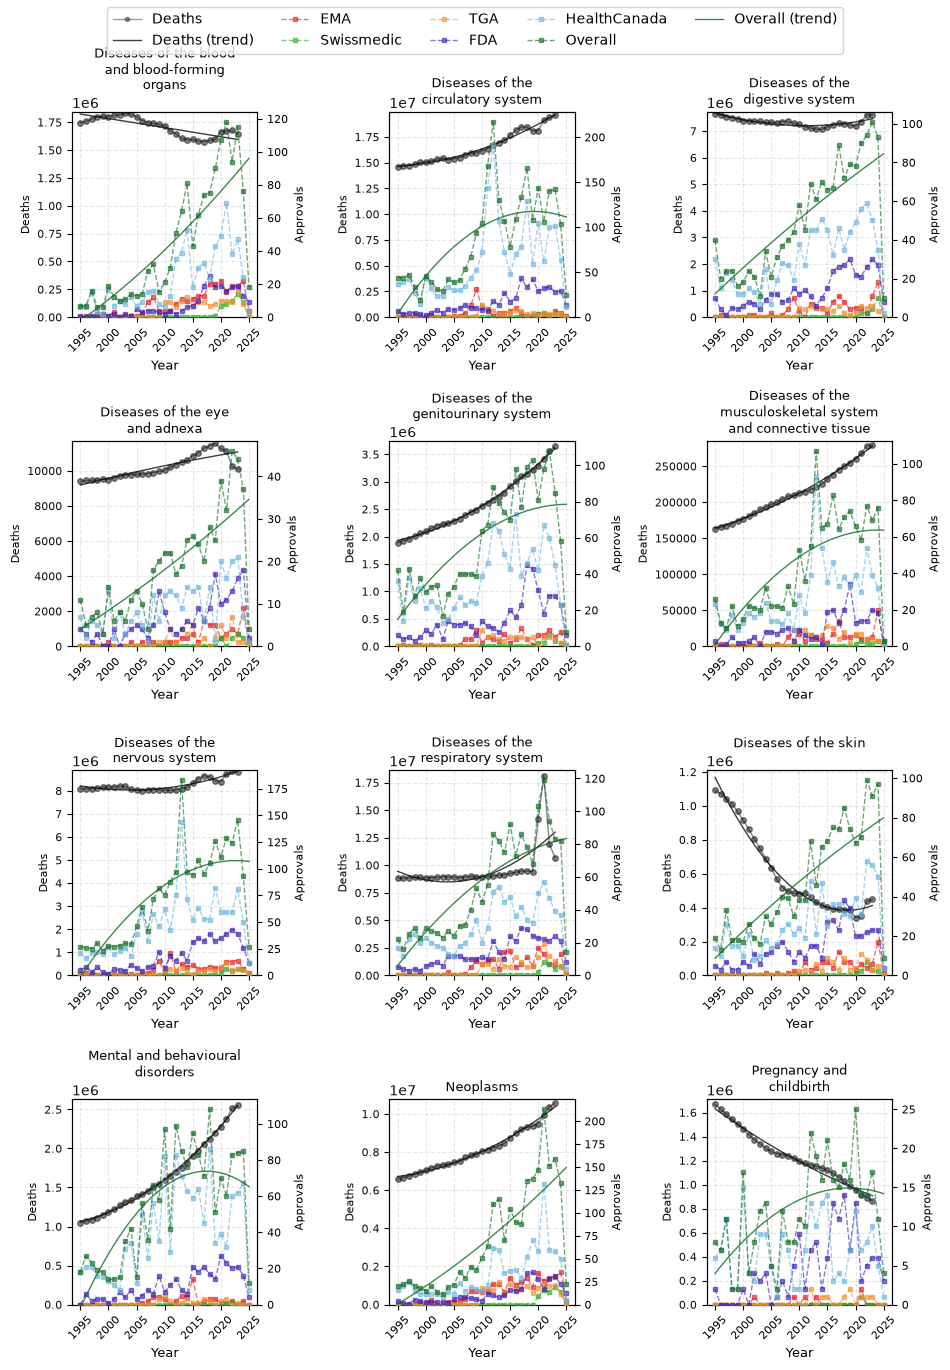

In [173]:
# Plot Deaths vs Drug Approvals for ALL datasets combined (1995+)
plot_burden_vs_approvals_combined(
    datasets_dict=DATASETS,
    burden_data=burden_deaths,
    date_col="Decision_year",
    disease_col="Disease_class(es)",
    measure="Deaths",
    ncols=3,
    figsize=(10, 14)
)

Processing datasets...
  - EMA
  - Swissmedic
  - TGA
  - FDA
  - HealthCanada
  - Overall
Found 12 disease classes
Year range: 1995 - 2025

Saved: /Users/shtosti/Dropbox/Projects/DrugFork/analysis/1995/approved/burden/incidence_vs_approvals_Decision_year.png


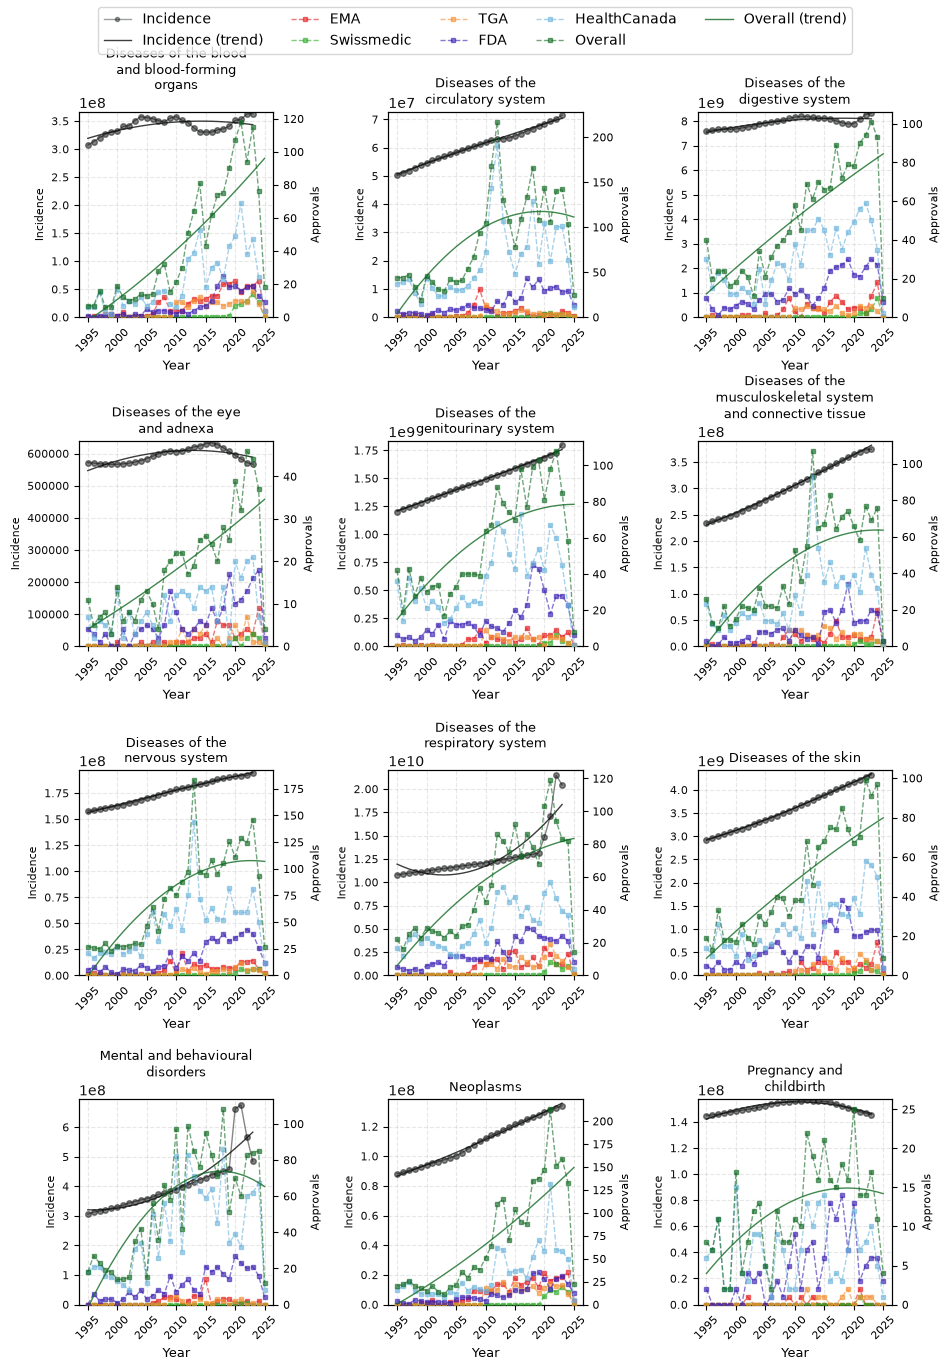

In [174]:
# Plot Prevalence vs Drug Approvals for ALL datasets combined (1995+)
plot_burden_vs_approvals_combined(
    datasets_dict=DATASETS,
    burden_data=burden_incidence,
    date_col="Decision_year",
    disease_col="Disease_class(es)",
    measure="Incidence",
    ncols=3,
    figsize=(10, 14)
)

Processing datasets...
  - EMA
  - Swissmedic
  - TGA
  - FDA
  - HealthCanada
  - Overall
Found 12 disease classes
Year range: 1995 - 2025

Saved: /Users/shtosti/Dropbox/Projects/DrugFork/analysis/1995/approved/burden/prevalence_vs_approvals_Decision_year.png


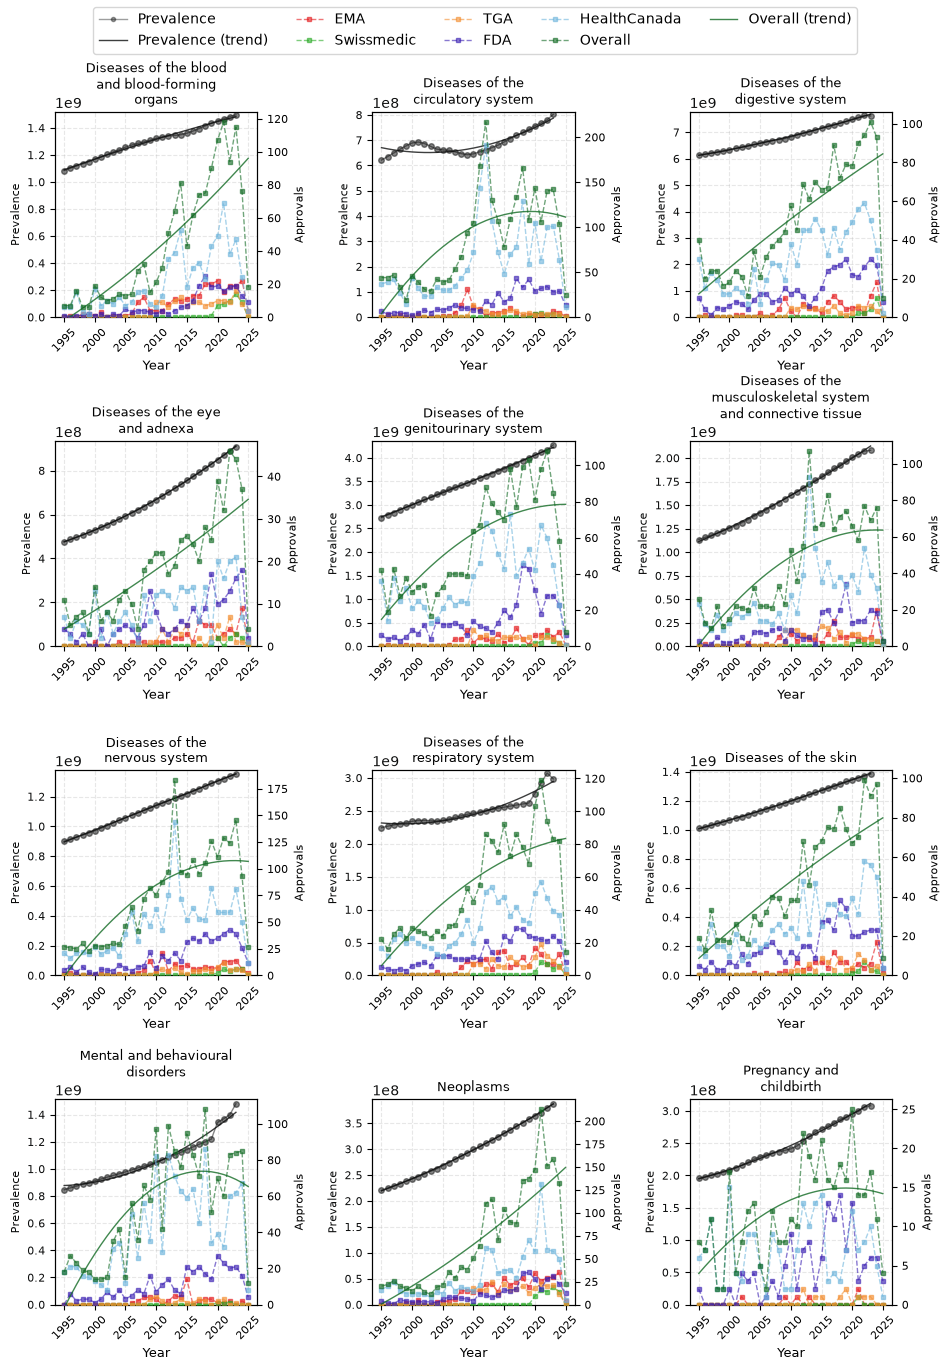

In [175]:
# Plot Prevalence vs Drug Approvals for ALL datasets combined (1995+)
plot_burden_vs_approvals_combined(
    datasets_dict=DATASETS,
    burden_data=burden_prevalence,
    date_col="Decision_year",
    disease_col="Disease_class(es)",
    measure="Prevalence",
    ncols=3,
    figsize=(10, 14)
)

In [176]:
# Investigate suspiciously short review durations
output_lines = []

for agency, df in DATASETS.items():
    if 'Application_date' in df.columns and 'Decision_date' in df.columns:
        df_check = df.copy()
        df_check['Application_date'] = pd.to_datetime(df_check['Application_date'], errors='coerce', dayfirst=True)
        df_check['Decision_date'] = pd.to_datetime(df_check['Decision_date'], errors='coerce', dayfirst=True)
        df_check['Review_duration_days'] = (df_check['Decision_date'] - df_check['Application_date']).dt.days
        
        # Filter for valid durations
        valid = df_check[df_check['Review_duration_days'].notna()]
        
        if len(valid) > 0:
            # Check for very short durations (< 30 days)
            very_short = valid[valid['Review_duration_days'] < 30]
            # Check for negative durations (decision before application!)
            negative = valid[valid['Review_duration_days'] < 0]
            
            output = f"\n{agency}:\n"
            output += f"  Total with both dates: {len(valid)}\n"
            output += f"  Review < 30 days: {len(very_short)} ({len(very_short)/len(valid)*100:.1f}%)\n"
            output += f"  Negative duration: {len(negative)} ({len(negative)/len(valid)*100:.1f}%)\n"
            
            if len(very_short) > 0:
                output += f"  Min duration: {valid['Review_duration_days'].min()} days\n"
                if len(very_short) <= 5:
                    output += f"  All cases < 30 days:\n"
                    output += very_short[['Drug_name', 'Application_date', 'Decision_date', 'Review_duration_days']].to_string() + "\n"
                else:
                    output += f"  First 3 examples of < 30 days:\n"
                    output += very_short[['Drug_name', 'Application_date', 'Decision_date', 'Review_duration_days']].head(3).to_string() + "\n"
            
            print(output)
            output_lines.append(output)

# Save to text file
output_file = f'{SAVE_DIR}/short_review_durations_analysis.txt'
with open(output_file, 'w', encoding='utf-8') as f:
    f.write("Analysis of Suspiciously Short Review Durations\n")
    f.write("=" * 60 + "\n")
    f.writelines(output_lines)

print(f"\nAnalysis saved to: {output_file}")


EMA:
  Total with both dates: 1396
  Review < 30 days: 11 (0.8%)
  Negative duration: 0 (0.0%)
  Min duration: 2.0 days
  First 3 examples of < 30 days:
     Drug_name Application_date Decision_date  Review_duration_days
72   arepanrix       2010-01-18    2010-01-20                   2.0
130   bimervax       2023-03-21    2023-03-30                   9.0
231  comirnaty       2020-11-30    2020-12-21                  21.0


Swissmedic:
  Total with both dates: 233
  Review < 30 days: 0 (0.0%)
  Negative duration: 0 (0.0%)


TGA:
  Total with both dates: 495
  Review < 30 days: 3 (0.6%)
  Negative duration: 0 (0.0%)
  Min duration: 4.0 days
  All cases < 30 days:
      Drug_name Application_date Decision_date  Review_duration_days
1837  comirnaty       2021-10-15    2021-10-26                  11.0
1983   spikevax       2021-11-08    2021-12-07                  29.0
2456    veklury       2020-07-06    2020-07-10                   4.0


Overall:
  Total with both dates: 2124
  Review < 3